# Tuần 07 — Khái quát dữ liệu (3/7): Kỳ vọng, phương sai và xấp xỉ chuẩn

**UET.MAT1052 — Xác suất thống kê**

ThS. Hoàng Hữu Bách — BM. Khoa học & Kỹ thuật tính toán - Khoa Công nghệ Thông tin, VNU-UET

Một cặp sản phẩm có thể có 0, 1 hoặc 2 sản phẩm đạt chuẩn. Nếu mỗi sản phẩm đạt chuẩn với xác suất 0,8, tại sao ta lại nói một cặp có **trung bình 1,6 sản phẩm đạt chuẩn**? Khi xử lý nhiều cặp, trung bình ấy ổn định đến đâu? Đây là hai câu hỏi dẫn bài học.

Buổi 6 cho ta cả bảng phân phối, thay vì chỉ một kết quả. Buổi này dùng bảng đó để tính trung tâm và mức dao động, rồi xem điều gì xảy ra khi cộng hoặc lấy trung bình nhiều kết quả ngẫu nhiên. Cuối buổi, ta tính xác suất bằng diện tích dưới đường mật độ và giải thích khi nào dùng được xấp xỉ chuẩn.

Sau khi học, bạn cần tính và diễn giải kỳ vọng, phương sai, độ lệch chuẩn; nhận ra vai trò của độc lập và cùng phân phối; mô hình hóa bằng chiếc hộp; dùng Chebyshev và giải thích luật số lớn yếu; đọc pdf/cdf; nhận diện các phân phối liên tục trong bài; áp dụng CLT với đúng giả định. Nội dung đáp ứng **LLO7.1/CLO2** và chuẩn bị ôn **LLO8.8** ở buổi giữa kỳ.

Notebook giữ đủ **15 Ví dụ và 10 Bài tập** của `Slides/week07.pdf` (94 trang), với nhãn và đáp án tương ứng. Các chi tiết Chebyshev, luật số lớn yếu, mũ, $\chi^2$ và $t$ Student đã có trong slide nên được giữ. Nguồn bổ trợ là STAT20 tiếng Việt §4.7–4.18. Mỗi cell ghi trang slide trong metadata để kiểm tra đối chiếu.

Hãy đọc phần tính tay trước, tự trả lời bài tập rồi mở đáp án. Cell có chú thích **Thử đổi** dành cho bạn sửa tham số. Toàn bộ phép thử ở đây được mô phỏng theo mô hình đã nêu; kết quả không phải số liệu điều tra thực tế.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype"
pio.templates.default = "simple_white"
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11})
pd.set_option("display.precision", 5)
rng = np.random.default_rng(42)

print("Seed = 42. Các bảng lý thuyết không đổi; các ước lượng mô phỏng có sai số ngẫu nhiên.")

Seed = 42. Các bảng lý thuyết không đổi; các ước lượng mô phỏng có sai số ngẫu nhiên.


## 1. Kỳ vọng: trung bình của những gì có thể xảy ra

### Ví dụ 1 — Hai sản phẩm đạt chuẩn

Kiểm tra **hai sản phẩm độc lập**, mỗi sản phẩm đạt chuẩn với xác suất $0{,}8$. Gọi $X$ là số sản phẩm đạt chuẩn. Ta có $P(X=0)=0{,}2^2=0{,}04$, $P(X=1)=2(0{,}8)(0{,}2)=0{,}32$, $P(X=2)=0{,}8^2=0{,}64$.

| $x$ (sản phẩm) | 0 | 1 | 2 |
|---|---:|---:|---:|
| $p_X(x)=P(X=x)$ | 0,04 | 0,32 | 0,64 |
| $x p_X(x)$ | 0 | 0,32 | 1,28 |

Nếu xử lý rất nhiều cặp, khoảng 4% cặp góp 0, 32% góp 1 và 64% góp 2 sản phẩm đạt chuẩn. Trung bình dài hạn vì vậy là $0+0{,}32+1{,}28=1{,}6$ sản phẩm trên mỗi cặp.

Với biến ngẫu nhiên rời rạc, **kỳ vọng (expected value)** là

$$E(X)=\sum_x x p_X(x),\qquad p_X(x)=P(X=x).$$

Tổng chạy qua các giá trị $x$ có thể nhận; xác suất $p_X(x)$ là trọng số, không có đơn vị; $E(X)$ có cùng đơn vị với $X$. Với miền giá trị vô hạn, định nghĩa hữu hạn này đòi hỏi $\sum_x |x|p_X(x)<\infty$. Trong các bảng hữu hạn đang dùng, điều kiện tự động thỏa mãn. Kỳ vọng là một hằng số của phân phối, còn $X$ là kết quả ngẫu nhiên.

**1,6 không phải một kết quả có thể quan sát của một cặp.** Nó mô tả trung bình khi lặp lại cùng cơ chế. Ta kiểm tra điều này bằng bảng lý thuyết và mô phỏng 5.000 cặp; histogram cho biết các kết quả vẫn chỉ là 0, 1, 2.

,x (sản phẩm),P(X=x),x P(X=x)
0,0,0.04,0.00
1,1,0.32,0.32
2,2,0.64,1.28


Kỳ vọng lý thuyết = 1.600; trung bình mô phỏng = 1.609


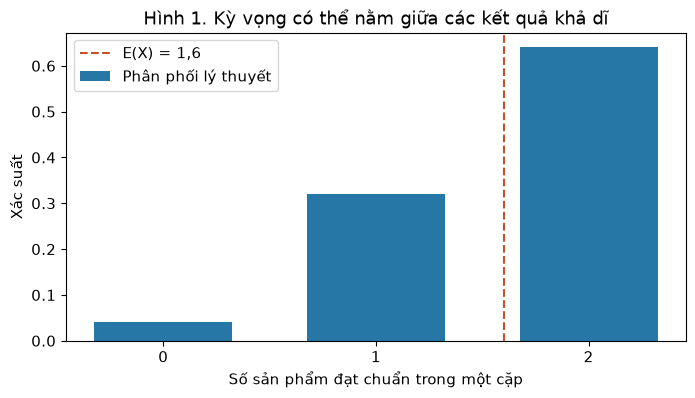

In [2]:
x_dat = np.arange(3)
p_dat = stats.binom.pmf(x_dat, n=2, p=0.8)
mu_dat = np.sum(x_dat * p_dat)
display(pd.DataFrame({"x (sản phẩm)": x_dat, "P(X=x)": p_dat,
                      "x P(X=x)": x_dat * p_dat}))
so_cap = 5000  # Thử đổi: số cặp được kiểm tra, không phải số sản phẩm mỗi cặp
dat_mo_phong = rng.binomial(n=2, p=0.8, size=so_cap)
print(f"Kỳ vọng lý thuyết = {mu_dat:.3f}; trung bình mô phỏng = {dat_mo_phong.mean():.3f}")
fig, ax = plt.subplots()
ax.bar(x_dat, p_dat, width=0.65, color="#2677A6", label="Phân phối lý thuyết")
ax.axvline(mu_dat, color="#C4512A", ls="--", label="E(X) = 1,6")
ax.set(xlabel="Số sản phẩm đạt chuẩn trong một cặp", ylabel="Xác suất", xticks=[0,1,2],
       title="Hình 1. Kỳ vọng có thể nằm giữa các kết quả khả dĩ")
ax.legend(); plt.show()

Trung bình mô phỏng ở gần 1,6, còn cột xác suất ở 1,6 không tồn tại. Tăng `so_cap` giúp ước lượng trung bình ổn định hơn; nó không thêm giá trị mới vào miền giá trị của $X$.

### Tính tuyến tính và Ví dụ 2 — Chi phí xử lý

Giả sử các kỳ vọng dưới đây hữu hạn. Với hằng số $a,b,c$:

| Tính chất | Công thức |
|---|---|
| Hằng số | $E(c)=c$ |
| Nhân hằng số | $E(aX)=aE(X)$ |
| Cộng | $E(X+Y)=E(X)+E(Y)$ |
| Tuyến tính | $E(aX+bY)=aE(X)+bE(Y)$ |

**Tính cộng của kỳ vọng không đòi hỏi độc lập.** Mỗi lần cộng hai đại lượng ta cộng phần đóng góp trung bình của chúng.

**Ví dụ 2.** Cơ sở kiểm tra hai sản phẩm độc lập, xác suất đạt chuẩn mỗi sản phẩm là 0,8; $X$ đếm số đạt chuẩn và $E(X)=1{,}6$. Chi phí cố định 50 nghìn đồng cho một cặp, cộng 20 nghìn đồng cho mỗi sản phẩm đạt chuẩn. (1) Viết chi phí $C$ theo $X$. (2) Tính và diễn giải $E(C)$.

<details><summary>Đáp án và cách lập luận</summary><div><p>$$C=50+20X\quad\text{(nghìn đồng)}.$$ $$E(C)=50+20E(X)=50+20(1{,}6)=82\text{ nghìn đồng}.$$ Khi xử lý nhiều cặp trong cùng điều kiện, chi phí trung bình mỗi cặp tiến gần 82 nghìn đồng. Chi phí từng cặp chỉ nhận 50, 70 hoặc 90 nghìn đồng.</p> </div></details>

Bảng tiếp theo kiểm tra bằng cách đổi từng giá trị $x$ thành chi phí tương ứng, giữ trọng số $p_X(x)$, rồi cộng. Hai cách phải cho cùng 82.

In [3]:
chi_phi = 50 + 20 * x_dat
display(pd.DataFrame({"X": x_dat, "C (nghìn đồng)": chi_phi,
                      "P": p_dat, "C nhân P": chi_phi * p_dat}))
print("E(C) =", np.sum(chi_phi * p_dat), "nghìn đồng")

,X,C (nghìn đồng),P,C nhân P
0,0,50,0.04,2.0
1,1,70,0.32,22.4
2,2,90,0.64,57.6


E(C) = 82.0 nghìn đồng


### Kỳ vọng của một hàm và Bài tập 1 — Chia bánh

Nếu $Y=g(X)$, tính trung bình các giá trị **sau biến đổi**:

$$E[g(X)]=\sum_x g(x)P(X=x).$$

Ta biến đổi giá trị $x$, rồi dùng xác suất gắn với $x$ trong tổng. Nếu nhiều $x$ cho cùng $g(x)$, xác suất của giá trị $Y$ đó là tổng các xác suất tương ứng. Vì vậy không thể nói phân phối của $Y$ giữ nguyên; cũng không được bình phương xác suất khi tính $E(X^2)$. Nói chung $E[g(X)]\ne g(E(X))$.

**Bài tập 1.** An mời hai người bạn đến ăn bánh. Mỗi người độc lập tung một đồng xu cân đối để quyết định có đến hay không. Bánh chia đều cho An và những người có mặt. Nếu $N$ là số bạn đến, phần bánh $X$ của An là 1, $1/2$, $1/3$ khi $N=0,1,2$. Tính $E(X)$ và so sánh với $1/E(N+1)$.

<details><summary>Đáp án và cách lập luận</summary><div><table> <thead> <tr>   <th>$n$</th>   <th style="text-align:right">0</th>   <th style="text-align:right">1</th>   <th style="text-align:right">2</th> </tr> </thead> <tbody> <tr>   <td>$P(N=n)$</td>   <td style="text-align:right">$1/4$</td>   <td style="text-align:right">$1/2$</td>   <td style="text-align:right">$1/4$</td> </tr> <tr>   <td>$X=1/(n+1)$</td>   <td style="text-align:right">1</td>   <td style="text-align:right">$1/2$</td>   <td style="text-align:right">$1/3$</td> </tr> </tbody> </table> <p>$$E(X)=1\left(\frac14\right)+\frac12\left(\frac12\right)+\frac13\left(\frac14\right)=\frac7{12}.$$ Trong khi đó $E(N)=1$, nên $1/E(N+1)=1/2$. Lấy trung bình trước rồi chia bánh là một phép tính khác với chia bánh từng lần rồi lấy trung bình.</p> </div></details>

Ta sẽ thấy sự khác biệt ngay khi lập hai cột “phần bánh” và “phần bánh nhân xác suất”.

In [4]:
n_ban = np.arange(3)
p_ban = stats.binom.pmf(n_ban, n=2, p=0.5)
phan_banh = 1 / (n_ban + 1)
display(pd.DataFrame({"N":n_ban,"P":p_ban,"X":phan_banh,"X nhân P":phan_banh*p_ban}))
print("E[1/(N+1)] =", np.dot(phan_banh,p_ban))
print("1/E[N+1] =", 1 / np.dot(n_ban+1,p_ban))

,N,P,X,X nhân P
0,0,0.25,1.00000,0.25000
1,1,0.50,0.50000,0.25000
2,2,0.25,0.33333,0.08333


E[1/(N+1)] = 0.5833333333333335
1/E[N+1] = 0.4999999999999999


### Kỳ vọng các phân phối rời rạc đã học

| Mô hình | Đại lượng được đếm | Kỳ vọng |
|---|---|---|
| Bernoulli$(p)$ | Thành công trong một phép thử | $p$ |
| Binomial$(n,p)$ | Thành công trong $n$ phép thử độc lập, cùng $p$ | $np$ |
| Hypergeometric$(N,K,n)$ | Thành công trong $n$ phần tử lấy không hoàn lại, tổng thể $N$ có $K$ thành công | $nK/N$ |
| Poisson$(\lambda)$ | Số sự kiện trên khoảng đã xác định | $\lambda$ |

Ký hiệu $K$ là số phần tử thành công **trong tổng thể**, khác với $n$ là cỡ mẫu. Với nhị thức, viết $X=I_1+\cdots+I_n$, mỗi $I_i$ là biến chỉ báo có kỳ vọng $p$, ta được $E(X)=np$. Siêu bội có các lần rút phụ thuộc nhưng kỳ vọng vẫn cộng được. Các tham số phải thỏa điều kiện của mô hình; công thức không tự quyết định mô hình nào phù hợp.

## 2. Phương sai và độ lệch chuẩn

### Ví dụ 3 — Cặp sản phẩm dao động bao nhiêu?

Vẫn là hai sản phẩm độc lập, xác suất đạt chuẩn 0,8 mỗi sản phẩm. Biết $\mu=E(X)=1{,}6$, ta hỏi kết quả của một cặp thường cách 1,6 bao xa. Khoảng cách có dấu cộng lại bằng 0; bình phương khoảng cách tránh việc dương và âm triệt tiêu:

$$\operatorname{Var}(X)=E[(X-\mu)^2]=\sum_x(x-\mu)^2p_X(x),\qquad
\operatorname{SD}(X)=\sqrt{\operatorname{Var}(X)}.$$

Phương sai có đơn vị bình phương; SD có cùng đơn vị với $X$. Giả sử phương sai hữu hạn. Cả hai không âm; SD bằng 0 khi $X$ là hằng số với xác suất 1.

$$\operatorname{Var}(X)=(0-1{,}6)^2(0{,}04)+(1-1{,}6)^2(0{,}32)+(2-1{,}6)^2(0{,}64)=0{,}32.$$
$$\operatorname{SD}(X)=\sqrt{0{,}32}\approx0{,}566\text{ sản phẩm}.$$

SD mô tả quy mô dao động, không có nghĩa mọi cặp sai khác kỳ vọng đúng 0,566 sản phẩm. Bảng sẽ cho thấy mỗi giá trị đóng góp bao nhiêu vào phương sai.

Khi $E(X^2)$ hữu hạn, công thức rút gọn là
$$\operatorname{Var}(X)=E(X^2)-[E(X)]^2.$$
Từ $E[(X-\mu)^2]=E(X^2)-2\mu E(X)+\mu^2$ và $E(X)=\mu$, ta thấy vì sao nó đúng. Với cặp sản phẩm, $E(X^2)=0^2(0{,}04)+1^2(0{,}32)+2^2(0{,}64)=2{,}88$, nên $2{,}88-1{,}6^2=0{,}32$.

In [5]:
bang_var = pd.DataFrame({"x":x_dat,"p":p_dat,"x²":x_dat**2,
                         "(x−μ)²":(x_dat-mu_dat)**2})
bang_var["Đóng góp phương sai"] = (x_dat-mu_dat)**2 * p_dat
display(bang_var)
var_dat = np.dot((x_dat-mu_dat)**2,p_dat)
var_rut_gon = np.dot(x_dat**2,p_dat) - mu_dat**2
print("Var trực tiếp / rút gọn / SD:", var_dat, var_rut_gon, np.sqrt(var_dat))
assert np.isclose(var_dat, 0.32) and np.isclose(var_dat,var_rut_gon)

,x,p,x²,(x−μ)²,Đóng góp phương sai
0,0,0.04,0,2.56,0.1024
1,1,0.32,1,0.36,0.1152
2,2,0.64,4,0.16,0.1024


Var trực tiếp / rút gọn / SD: 0.31999999999999995 0.3199999999999994 0.565685424949238


### Biến đổi đơn vị và Bài tập 2 — Celsius sang Fahrenheit

Với phương sai hữu hạn và các hằng số $a,b,c$:

$$\operatorname{Var}(c)=0,\quad \operatorname{Var}(X+b)=\operatorname{Var}(X),$$
$$\operatorname{Var}(aX+b)=a^2\operatorname{Var}(X),\quad
\operatorname{SD}(aX+b)=|a|\operatorname{SD}(X).$$

Dịch cả phân phối thêm $b$ không thay khoảng cách đến kỳ vọng. Nhân giá trị với $a$ làm khoảng cách nhân $|a|$, còn bình phương khoảng cách nhân $a^2$. Dấu trị tuyệt đối bảo đảm SD không âm, kể cả khi $a<0$.

**Bài tập 2.** Nhiệt độ $X$ theo độ C có $E(X)=25$ và $\operatorname{SD}(X)=3$. Đặt $Y=1{,}8X+32$ theo độ F. Tính $E(Y)$, $\operatorname{Var}(Y)$, $\operatorname{SD}(Y)$.

<details><summary>Đáp án và cách lập luận</summary><div><p>$$E(Y)=1{,}8(25)+32=77\,{}^\circ\mathrm F,$$ $$\operatorname{Var}(Y)=1{,}8^2(3^2)=29{,}16\,({}^\circ\mathrm F)^2,$$ $$\operatorname{SD}(Y)=1{,}8(3)=5{,}4\,{}^\circ\mathrm F.$$ Cộng 32 chỉ dịch trung tâm. Nhân 1,8 mới làm độ phân tán đổi.</p> </div></details>

### Cộng hai biến: khi nào được cộng phương sai?

Hai biến $X,Y$ độc lập khi, với mọi tập giá trị thích hợp $A,B$, $P(X\in A,Y\in B)=P(X\in A)P(Y\in B)$. Biết giá trị biến này không cung cấp thông tin về phân phối biến kia. Nếu độc lập:

$$\operatorname{Var}(X+Y)=\operatorname{Var}(X-Y)=\operatorname{Var}(X)+\operatorname{Var}(Y).$$

SD **không cộng**: phải cộng phương sai rồi mới lấy căn. Với các biến phụ thuộc, công thức tổng quát chứa hiệp phương sai:
$$\operatorname{Var}(X\pm Y)=\operatorname{Var}(X)+\operatorname{Var}(Y)\pm2\operatorname{Cov}(X,Y),$$
trong đó $\operatorname{Cov}(X,Y)=E[(X-E(X))(Y-E(Y))]$. Hiệp phương sai là phần đo hai biến cùng lệch như thế nào. Đây là cách thấy vì sao cần giả định; chưa cần học sâu về hiệp phương sai.

Cell tiếp theo so sánh $X+Y$ với $X+X$. Hai biến được tạo độc lập có phương sai tổng gần 2; hai lần dùng cùng $X$ có phương sai gần 4, dù kỳ vọng vẫn cộng được.

In [6]:
print("Fahrenheit: E =",1.8*25+32,"; Var =",1.8**2*9,"; SD =",1.8*3)
x_doc_lap = rng.choice([-1,1],size=20000)
y_doc_lap = rng.choice([-1,1],size=20000)
print("Var(X+Y), X,Y độc lập:",np.var(x_doc_lap+y_doc_lap))
print("Var(X+X), hai biến cùng là X:",np.var(x_doc_lap+x_doc_lap))
print("E(X+X) và 2E(X):",(x_doc_lap+x_doc_lap).mean(),2*x_doc_lap.mean())

Fahrenheit: E = 77.0 ; Var = 29.160000000000004 ; SD = 5.4
Var(X+Y), X,Y độc lập: 2.0039190000000002
Var(X+X), hai biến cùng là X: 3.99992944
E(X+X) và 2E(X): 0.0084 0.0084


### Phương sai các phân phối rời rạc đặc biệt

| Mô hình | Phương sai | SD |
|---|---|---|
| Bernoulli$(p)$ | $p(1-p)$ | $\sqrt{p(1-p)}$ |
| Binomial$(n,p)$ | $np(1-p)$ | $\sqrt{np(1-p)}$ |
| Poisson$(\lambda)$ | $\lambda$ | $\sqrt\lambda$ |
| Hypergeometric$(N,K,n)$, $p=K/N$, $N>1$ | $np(1-p)\dfrac{N-n}{N-1}$ | Căn bậc hai của phương sai |

Bernoulli có $X^2=X$, nên $E(X^2)-E(X)^2=p-p^2$. Nhị thức là tổng $n$ biến Bernoulli độc lập nên phương sai là $np(1-p)$. Siêu bội có hệ số $(N-n)/(N-1)$ do lấy không hoàn lại; nếu lấy cả tổng thể ($n=N$), số thành công không còn ngẫu nhiên và phương sai bằng 0. Khi $N=1$, tính trực tiếp từ hộp thay vì dùng công thức có mẫu $N-1$.

### Từ STAT20: cùng kỳ vọng, khác phân phối (bổ trợ)

Xúc xắc cân đối có $E(X)=3{,}5$, phương sai $35/12\approx2{,}9167$. Xúc xắc lệch có xác suất ở các mặt 1–6 lần lượt $(0{,}1;0{,}3;0{,}1;0{,}2;0{,}1;0{,}2)$ cũng có $E(X)=3{,}5$ nhưng phương sai $2{,}85$. Kỳ vọng bằng nhau không có nghĩa phân phối bằng nhau. Các hình này dựng lại các biểu đồ ở STAT20 §4.8.1, §4.10.

Ở cell sau, mỗi trục con là một bảng xác suất được vẽ thành cột, đường đỏ là kỳ vọng. Đừng dựa vào mỗi đường đỏ để đoán hình dạng.

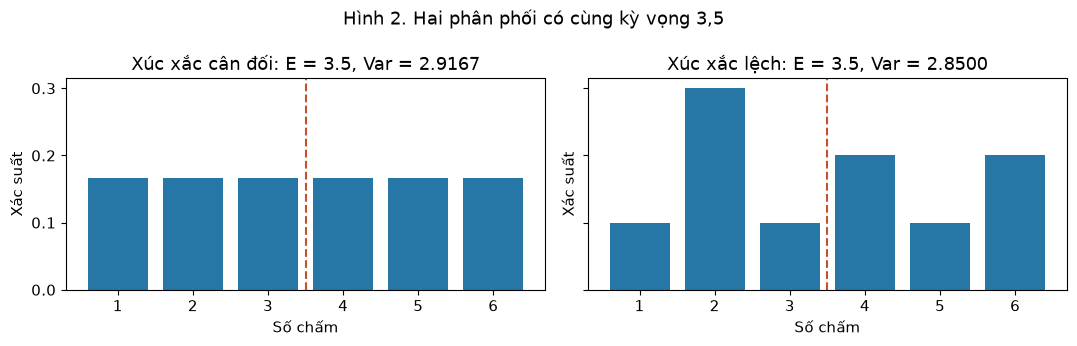

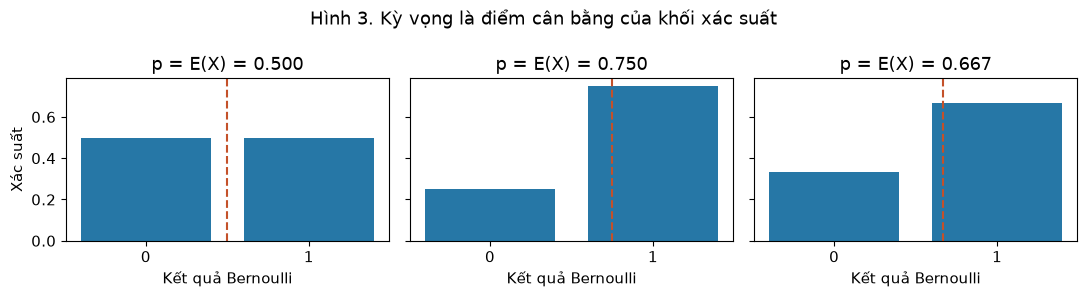

In [7]:
x_xuc_xac = np.arange(1,7)
p_can_doi = np.repeat(1/6,6)
p_lech = np.array([0.1,0.3,0.1,0.2,0.1,0.2])
fig, axes = plt.subplots(1,2,figsize=(11,3.5),sharey=True)
for ax,p,t in zip(axes,[p_can_doi,p_lech],["Xúc xắc cân đối","Xúc xắc lệch"]):
    mu = np.dot(x_xuc_xac,p); var = np.dot((x_xuc_xac-mu)**2,p)
    ax.bar(x_xuc_xac,p,color="#2677A6")
    ax.axvline(mu,color="#C4512A",ls="--")
    ax.set(xlabel="Số chấm",ylabel="Xác suất",title=f"{t}: E = {mu:.1f}, Var = {var:.4f}")
fig.suptitle("Hình 2. Hai phân phối có cùng kỳ vọng 3,5"); fig.tight_layout(); plt.show()
fig, axes = plt.subplots(1,3,figsize=(11,3),sharey=True)
for ax,p in zip(axes,[0.5,0.75,2/3]):
    ax.bar([0,1],[1-p,p],color="#2677A6")
    ax.axvline(p,color="#C4512A",ls="--")
    ax.set(xticks=[0,1],xlabel="Kết quả Bernoulli",title=f"p = E(X) = {p:.3f}")
axes[0].set_ylabel("Xác suất");fig.suptitle("Hình 3. Kỳ vọng là điểm cân bằng của khối xác suất");fig.tight_layout();plt.show()

Trong hai hình xúc xắc, các cột phân bố khác nhau dù cùng trung tâm. Với Bernoulli, tâm dịch về 1 khi xác suất thành công tăng. Không có quy tắc rằng kỳ vọng luôn là kết quả có xác suất lớn nhất.

## 3. Nhiều lần rút: độc lập, cùng phân phối và chiếc hộp

Các biến $X_1,\ldots,X_n$ **độc lập và cùng phân phối (i.i.d.)** khi chúng độc lập với nhau và có cùng quy luật xác suất, nghĩa là cùng cdf. Với biến rời rạc chúng cũng có cùng pmf; với biến có mật độ chúng có cùng phân phối mật độ. Ta dùng định nghĩa qua cdf để bao gồm cả rời rạc và liên tục. Độc lập đôi một riêng lẻ chưa đủ để nói mọi biến cùng độc lập.

Tung độc lập một đồng xu nhiều lần với cùng xác suất ngửa là một ví dụ. Cùng trung bình và cùng phương sai **chưa đủ** để kết luận cùng phân phối.

**Mô hình chiếc hộp**: ghi các giá trị lên các lá thăm; mỗi lá có cùng xác suất được rút. Lá khác nhau có thể ghi cùng một số. Rút **độc lập, có hoàn lại từ cùng hộp** tạo các biến iid. Kỳ vọng là trung bình các số trong hộp; phương sai là trung bình bình phương độ lệch, chia số lá trong hộp, không chia số lá trừ 1. Hộp hữu hạn biểu diễn chính xác phân phối hữu hạn có xác suất là bội của một đơn vị chung; với phân phối khác có thể dùng trọng số hoặc xấp xỉ.

### Ví dụ 4 — Tổng hai xúc xắc bằng mô hình hộp

Hộp có sáu lá 1,2,3,4,5,6. Rút một lá được $X_1$ có phân phối đều rời rạc; hoàn lại, trộn đều rồi rút lần hai được $X_2$. Cặp $(X_1,X_2)$ mô hình hóa hai xúc xắc độc lập. $S=X_1+X_2$ là tổng số chấm; $X_1,X_2$ đều nhưng $S$ không đều vì có nhiều cách được tổng 7 hơn tổng 2.

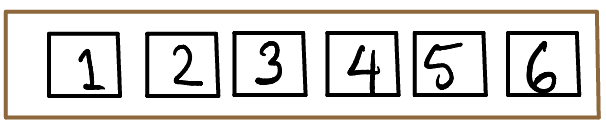

**Hình S1. Hộp sáu lá thăm cho một lần gieo xúc xắc.** Nguồn: `STAT20_in_Vietnamese.html`, mục 4.13.1.1. [Tệp ảnh gốc](figures/01_stat20_die_box.jpg).

In [8]:
hai_lan_rut = rng.choice(x_xuc_xac, size=(5000,2), replace=True)
tong_hai = hai_lan_rut.sum(axis=1)
print("Mỗi hàng là hai lần gieo; 5 hàng đầu:"); print(hai_lan_rut[:5])
print("E(tổng) lý thuyết = 7; mô phỏng =",tong_hai.mean())

Mỗi hàng là hai lần gieo; 5 hàng đầu:
[[1 6]
 [4 6]
 [3 5]
 [2 3]
 [3 4]]
E(tổng) lý thuyết = 7; mô phỏng = 7.0112


### Ví dụ 5 — Hộp 10 lá thăm

Hộp ghi $0,0,1,1,1,2,3,3,4,4$. Rút ngẫu nhiên một lá, xác suất mỗi lá $1/10$. Gọi $X$ là số ghi trên lá. (1) Lập bảng phân phối. (2) Tính kỳ vọng, phương sai và SD.

<details><summary>Đáp án và cách lập luận</summary><div><table> <thead> <tr>   <th>$x$</th>   <th style="text-align:right">0</th>   <th style="text-align:right">1</th>   <th style="text-align:right">2</th>   <th style="text-align:right">3</th>   <th style="text-align:right">4</th> </tr> </thead> <tbody> <tr>   <td>$P(X=x)$</td>   <td style="text-align:right">0,2</td>   <td style="text-align:right">0,3</td>   <td style="text-align:right">0,1</td>   <td style="text-align:right">0,2</td>   <td style="text-align:right">0,2</td> </tr> </tbody> </table> <p>$$E(X)=0(0{,}2)+1(0{,}3)+2(0{,}1)+3(0{,}2)+4(0{,}2)=1{,}9,$$ $$E(X^2)=0+0{,}3+0{,}4+1{,}8+3{,}2=5{,}7,$$ $$\operatorname{Var}(X)=5{,}7-1{,}9^2=2{,}09,\quad \operatorname{SD}(X)=\sqrt{2{,}09}\approx1{,}4457.$$ Số 1 có xác suất 3/10 do xuất hiện trên ba lá, không phải do số 1 tự được gán trọng số tùy ý.</p> </div></details>

**Đối chiếu nguồn:** slide và hình hộp STAT20 có 10 lá. Một dòng R trong STAT20 §4.14.1 vô tình ghi ba số 3, tạo 11 lá, không khớp $E=1{,}9$, $\operatorname{Var}=2{,}09$. Notebook dùng đúng hộp 10 lá của slide và pmf trong nguồn.

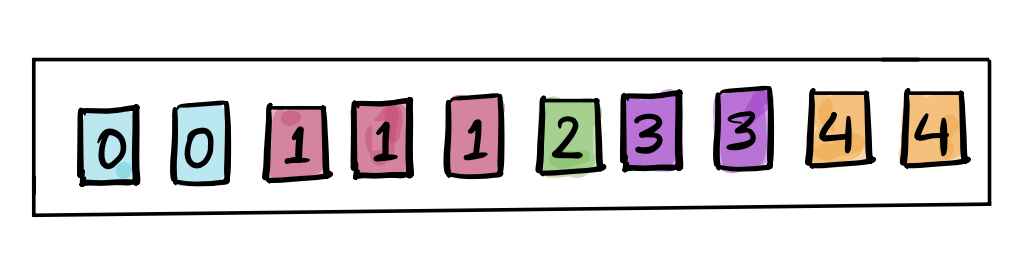

**Hình S2. Hộp 10 lá thăm dùng cho Ví dụ 5, 6 và 14.** Nguồn: `STAT20_in_Vietnamese.html`, mục 4.13. [Tệp ảnh gốc](figures/02_stat20_ten_ticket_box.png).

In [9]:
hop = np.array([0,0,1,1,1,2,3,3,4,4])
gia_tri_hop,so_la = np.unique(hop,return_counts=True)
p_hop = so_la / len(hop)
mu_hop = hop.mean()
var_hop = hop.var(ddof=0)  # Hộp là cả phân phối đang mô hình hóa
sd_hop = np.sqrt(var_hop)
display(pd.DataFrame({"x":gia_tri_hop,"Số lá":so_la,"P(X=x)":p_hop}))
print("E, E(X²), Var, SD:",mu_hop,np.mean(hop**2),var_hop,sd_hop)
assert len(hop)==10 and np.isclose(mu_hop,1.9) and np.isclose(var_hop,2.09)

,x,Số lá,P(X=x)
0,0,2,0.2
1,1,3,0.3
2,2,1,0.1
3,3,2,0.2
4,4,2,0.2


E, E(X²), Var, SD: 1.9 5.7 2.0900000000000003 1.445683229480096


### Tổng và trung bình: công thức trước khi xấp xỉ

Nếu $X_1,\ldots,X_n$ iid, mỗi biến có kỳ vọng $\mu$ và phương sai hữu hạn $\sigma^2$, đặt
$$S_n=\sum_{i=1}^n X_i,\qquad \overline X_n=S_n/n.$$

| Đại lượng | Kỳ vọng | Phương sai | SD |
|---|---|---|---|
| Tổng $S_n$ | $n\mu$ | $n\sigma^2$ | $\sigma\sqrt n$ |
| Trung bình $\overline X_n$ | $\mu$ | $\sigma^2/n$ | $\sigma/\sqrt n$ |

Tính cộng kỳ vọng cho $E(S_n)=n\mu$; độc lập cho $\operatorname{Var}(S_n)=n\sigma^2$. Vì chia cho $n$ làm phương sai chia cho $n^2$, phương sai của trung bình là $\sigma^2/n$. Các công thức này **đúng với mọi $n\ge1$**, không cần phân phối chuẩn hay CLT. Đơn vị của tổng và trung bình vẫn là đơn vị của mỗi $X_i$; số hạng $n$ không có đơn vị.

### Ví dụ 6 — Rút 25 lần rồi tăng lên 100

Dùng hộp 10 lá trên, rút độc lập có hoàn lại $n$ lần. Biết $\mu=1{,}9$, $\sigma^2=2{,}09$. (1) Tính kỳ vọng và SD của tổng và trung bình khi $n=25$. (2) Tính lại khi $n=100$.

<details><summary>Đáp án và cách lập luận</summary><div><table> <thead> <tr>   <th>Đại lượng</th>   <th style="text-align:right">$n=25$</th>   <th style="text-align:right">$n=100$</th> </tr> </thead> <tbody> <tr>   <td>$E(S_n)$</td>   <td style="text-align:right">47,5</td>   <td style="text-align:right">190</td> </tr> <tr>   <td>$\operatorname{SD}(S_n)$</td>   <td style="text-align:right">$\sqrt{25(2{,}09)}\approx7{,}228$</td>   <td style="text-align:right">$\sqrt{100(2{,}09)}\approx14{,}457$</td> </tr> <tr>   <td>$E(\overline X_n)$</td>   <td style="text-align:right">1,9</td>   <td style="text-align:right">1,9</td> </tr> <tr>   <td>$\operatorname{SD}(\overline X_n)$</td>   <td style="text-align:right">$\sqrt{2{,}09/25}\approx0{,}289$</td>   <td style="text-align:right">$\sqrt{2{,}09/100}\approx0{,}145$</td> </tr> </tbody> </table> <p>Cỡ mẫu tăng gấp 4 làm SD của tổng tăng gấp 2 nhưng SD của trung bình giảm một nửa.</p> </div></details>

Trong cell sau, một **hàng** là một mẫu gồm $n$ lần rút, một **cột** là một vị trí rút. `axis=1` cộng hoặc lấy trung bình theo hàng. `so_lan_lap=5000` tạo 5.000 tổng hoặc trung bình; nó khác với cỡ mẫu $n$.

In [10]:
so_lan_lap = 5000  # Thử đổi: số mẫu lặp để quan sát phân phối
co_mau = [25,100]   # Thử thêm cỡ mẫu; giữ 25 và 100 để đối chiếu hình/slide phía sau
ket_qua_hop = {}
bang_so_sanh = []
for n in co_mau:
    mau = rng.choice(hop,size=(so_lan_lap,n),replace=True)
    tong = mau.sum(axis=1)
    trung_binh = mau.mean(axis=1)
    ket_qua_hop[n] = {"tong":tong,"trung_binh":trung_binh}
    bang_so_sanh.append({"n":n,"E tổng":n*mu_hop,"TB các tổng":tong.mean(),
                         "SD tổng lý thuyết":sd_hop*np.sqrt(n),"SD tổng mô phỏng":tong.std(ddof=0),
                         "E trung bình":mu_hop,"TB các trung bình":trung_binh.mean(),
                         "SD trung bình lý thuyết":sd_hop/np.sqrt(n),
                         "SD trung bình mô phỏng":trung_binh.std(ddof=0)})
display(pd.DataFrame(bang_so_sanh).set_index("n"))

,E tổng,TB các tổng,SD tổng lý thuyết,SD tổng mô phỏng,E trung bình,TB các trung bình,SD trung bình lý thuyết,SD trung bình mô phỏng
n,,,,,,,,
25,47.5,47.5928,7.22842,7.42346,1.9,1.90371,0.28914,0.29694
100,190.0,189.8150,14.45683,14.43881,1.9,1.89815,0.14457,0.14439


Các ước lượng không cần trùng từng chữ số với slide dùng seed 2026. Với seed 42, chúng vẫn gần các giá trị lý thuyết. `std(ddof=0)` đang mô tả toàn bộ tập kết quả mô phỏng; đó không phải công thức $s$ ước lượng từ một mẫu nhỏ. Kết quả đúng cần phân biệt SD của một lá, SD của tổng và SD của trung bình.

### Từ STAT20: bước đi ngẫu nhiên và roulette (bổ trợ)

Mỗi phút một người đi thêm $+1$ hoặc $-1$ bước, độc lập với xác suất $1/2$ mỗi hướng. Vị trí sau $n$ phút là $S_n$, không phải tổng quãng đường đi được (quãng đường bằng $n$). Một bước có $E(X)=0$, $\operatorname{Var}(X)=1$; vì vậy $E(S_n)=0$, $\operatorname{SD}(S_n)=\sqrt n$.

Cell vẽ một đường đi 30 bước và phân phối điểm cuối của nhiều đường đi khác nhau. Trục thời gian của hình trái không có nghĩa người đó đi theo hai chiều; vị trí vẫn trên một trục. Sau 30 bước vị trí chỉ có thể là số chẵn. Với $S_{30}=2B-30$, $B\sim\operatorname{Bin}(30,0{,}5)$, ta có $P(S_{30}=4)=P(B=17)$.

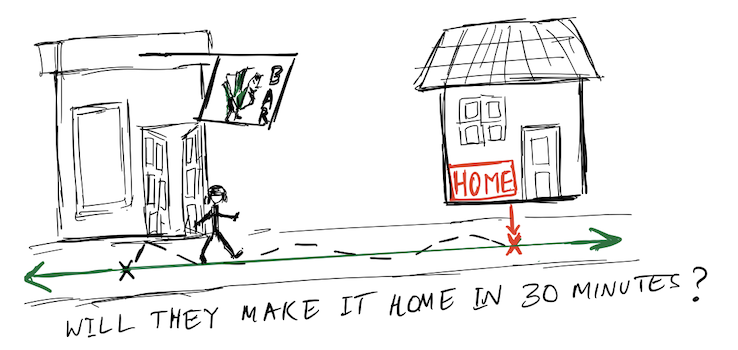

**Hình S3. Một bước đi ngẫu nhiên trên đường thẳng.** Nguồn: `STAT20_in_Vietnamese.html`, mục 4.12. [Tệp ảnh gốc](figures/03_stat20_random_walk_scene.png).

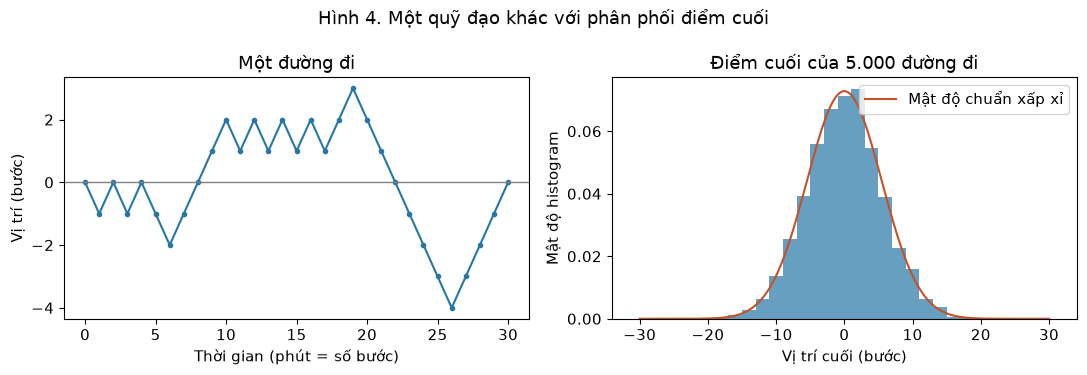

P(S30 = 4) chính xác: 0.1115350518375634


In [11]:
n_buoc = 30  # Thử đổi; n quyết định miền giá trị và SD điểm cuối
buoc = rng.choice([-1,1],size=n_buoc)
vi_tri = np.r_[0,buoc.cumsum()]
diem_cuoi = rng.choice([-1,1],size=(5000,n_buoc)).sum(axis=1)
fig,axes = plt.subplots(1,2,figsize=(11,3.8))
axes[0].plot(np.arange(n_buoc+1),vi_tri,marker=".",color="#2677A6")
axes[0].axhline(0,color="gray",lw=1)
axes[0].set(xlabel="Thời gian (phút = số bước)",ylabel="Vị trí (bước)",title="Một đường đi")
axes[1].hist(diem_cuoi,bins=np.arange(-n_buoc-1,n_buoc+2,2),density=True,color="#2677A6",alpha=0.7)
luoi = np.linspace(-n_buoc,n_buoc,300)
axes[1].plot(luoi,stats.norm.pdf(luoi,scale=np.sqrt(n_buoc)),color="#C4512A",label="Mật độ chuẩn xấp xỉ")
axes[1].set(xlabel="Vị trí cuối (bước)",ylabel="Mật độ histogram",title="Điểm cuối của 5.000 đường đi")
axes[1].legend();fig.suptitle("Hình 4. Một quỹ đạo khác với phân phối điểm cuối");fig.tight_layout();plt.show()
print("P(S30 = 4) chính xác:",stats.binom.pmf(17,n=30,p=0.5))

Đường cong chuẩn xấp xỉ hình dạng của phân phối, còn xác suất ở một vị trí rời rạc được tính bằng nhị thức. Đừng dùng xác suất tại một điểm của chuẩn để tính $P(S_{30}=4)$; chuẩn liên tục có xác suất tại một điểm bằng 0.

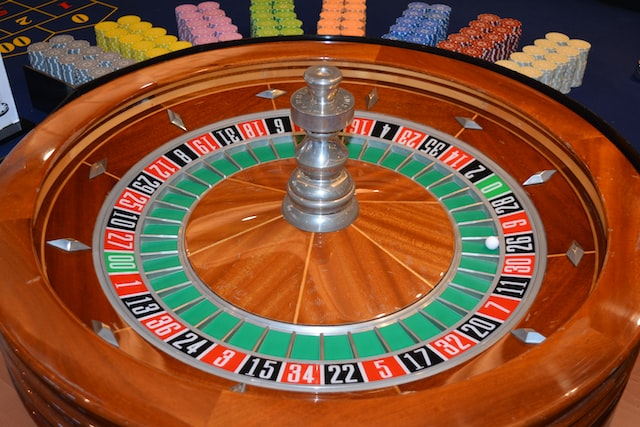

**Hình S4. Bánh xe roulette kiểu Mỹ: 18 đỏ, 18 đen và 2 xanh.** Nguồn: `STAT20_in_Vietnamese.html`, mục 4.13.1.2. [Tệp ảnh gốc](figures/04_stat20_roulette_photo.jpg).

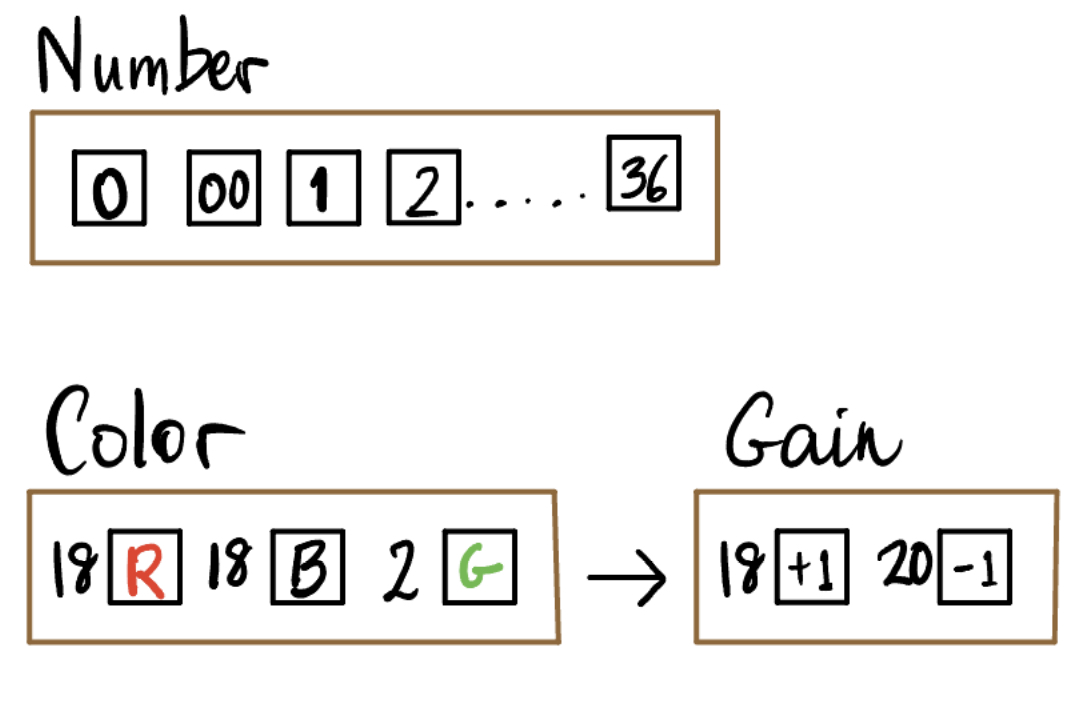

**Hình S5. Từ ô trên bánh xe sang hộp lợi nhuận: 18 lá +1, 20 lá −1.** Nguồn: `STAT20_in_Vietnamese.html`, mục 4.13.1.2. [Tệp ảnh gốc](figures/05_stat20_roulette_gain_box.jpg).

Cược 1 đô la vào đỏ: lợi nhuận ròng $G=+1$ với xác suất $18/38$, $G=-1$ với xác suất $20/38$ (cả đen và xanh đều thua). Tiền cược trả lại khi thắng không phải lợi nhuận mới. $E(G)=-1/19\approx-0{,}05263$ đô la; $E(G^2)=1$, nên $\operatorname{Var}(G)=1-1/19^2$. Tổng lợi nhuận sau $n$ lượt độc lập có kỳ vọng $-n/19$ nhưng vẫn có thể dương ở một lần chơi cụ thể. Ta sẽ quay lại tổng này ở phần CLT.

## 4. Cận xác suất và luật số lớn yếu

### Chebyshev không yêu cầu hình chuông

Nếu $X$ có kỳ vọng $\mu$, phương sai hữu hạn $\sigma^2$, với mọi mức sai lệch $\varepsilon>0$:

$$P(|X-\mu|\ge\varepsilon)\le\frac{\sigma^2}{\varepsilon^2}.$$

$\varepsilon$ có cùng đơn vị với $X$; tỉ số không có đơn vị nên có thể so với xác suất. Đây là **cận trên**, không phải xác suất chính xác. Cận hữu ích có thể lấy $\min(1,\sigma^2/\varepsilon^2)$. Với trung bình $n$ biến iid, thay phương sai bằng $\sigma^2/n$:
$$P(|\overline X_n-\mu|\ge\varepsilon)\le\frac{\sigma^2}{n\varepsilon^2}.$$

### Bài tập 3 — Đo nhiệt độ lò sấy

Mỗi phép đo nhiệt độ lò là không chệch: $E(X_i)=\mu$, nhiệt độ thật. Các phép đo iid, SD $1\,{}^\circ$C. Tìm số lần đo đủ để xác suất trung bình sai khác nhiệt độ thật không quá $0{,}2\,{}^\circ$C đạt ít nhất 99%, dùng Chebyshev; không giả định chuẩn.

<details><summary>Đáp án và cách lập luận</summary><div><p>$$P(|\overline X_n-\mu|&gt;0{,}2)\le\frac1{n(0{,}2)^2}=\frac{25}{n}.$$ Muốn cận trên không quá $0{,}01$, cần $25/n\le0{,}01$, tức $n\ge2500$. <strong>2.500 lần đủ theo cận</strong>, không nhất thiết là số tối thiểu cho phân phối thực tế. Không chệch và độc lập là giả định cần thiết của cách tính này.</p> </div></details>

Trong bảng dưới, tăng $n$ làm cận sai lệch giảm. Không cần mô phỏng 2.500 phép đo để chứng minh bảo đảm; bảo đảm được suy ra từ bất đẳng thức.

In [12]:
epsilon = 0.2  # Thử đổi mức sai lệch cho phép (độ C)
xac_suat_sai_toi_da = 0.01
n_du = int(np.ceil(1 / (xac_suat_sai_toi_da * epsilon**2)))
print("Số lần đo đủ theo Chebyshev:",n_du)
display(pd.DataFrame({"n":[100,500,2500,10000],
                      "Cận trên xác suất sai lệch":[min(1,1/(n*epsilon**2)) for n in [100,500,2500,10000]]}))

Số lần đo đủ theo Chebyshev: 2500


,n,Cận trên xác suất sai lệch
0,100,0.2500
1,500,0.0500
2,2500,0.0100
3,10000,0.0025


### Luật số lớn yếu và Bài tập 4 — Đồng xu có “bù” không?

Cho $X_1,X_2,\ldots$ iid, $E|X_1|<\infty$, kỳ vọng $\mu$. Với mọi $\varepsilon>0$:

$$P(|\overline X_n-\mu|>\varepsilon)\longrightarrow0\quad(n\longrightarrow\infty).$$

Đó là **hội tụ theo xác suất**: xác suất trung bình sai quá mức đã chọn giảm về 0. Nếu phương sai hữu hạn, Chebyshev giải thích vì cận $\sigma^2/(n\varepsilon^2)$ tiến về 0. Phát biểu luật số lớn yếu không bắt buộc có phương sai hữu hạn. Một đường mô phỏng chỉ minh họa, không chứng minh định lý và không bảo đảm hội tụ đơn điệu.

**Bài tập 4.** Sau 10 lần tung đồng xu cân đối đều ra sấp, luật số lớn có bảo đảm lần thứ 11 ra ngửa không? Tỉ lệ mặt ngửa có buộc tăng đều về 0,5 không?

<details><summary>Đáp án và cách lập luận</summary><div><p>Không. Nếu các lần tung độc lập, xác suất ngửa lần 11 vẫn là 0,5. Tỉ lệ tích lũy có thể tăng hoặc giảm. Luật số lớn nói về xác suất sai lệch của trung bình khi cỡ mẫu tăng; nó không làm đồng xu nhớ 10 kết quả cũ và không hứa mỗi bước đi gần kỳ vọng hơn.</p> </div></details>

Hình sau dựng lại minh họa slide 38: đồng xu có $p=0{,}7$. Hãy quan sát đoạn tăng và giảm quanh đường ngang 0,7, thay vì mong đường luôn tiến gần hơn.

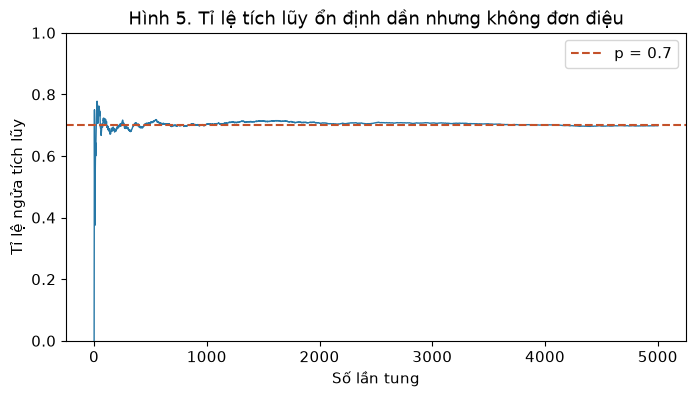

In [13]:
p_ngua = 0.7  # Thử đổi xác suất ngửa
so_lan_tung = 5000
tung = rng.binomial(1,p_ngua,size=so_lan_tung)
ty_le_tich_luy = tung.cumsum()/np.arange(1,so_lan_tung+1)
fig,ax = plt.subplots()
ax.plot(np.arange(1,so_lan_tung+1),ty_le_tich_luy,color="#2677A6",lw=1)
ax.axhline(p_ngua,color="#C4512A",ls="--",label=f"p = {p_ngua}")
ax.set(xlabel="Số lần tung",ylabel="Tỉ lệ ngửa tích lũy",ylim=(0,1),
       title="Hình 5. Tỉ lệ tích lũy ổn định dần nhưng không đơn điệu")
ax.legend();plt.show()

Thử giảm `so_lan_tung` xuống 50 để nhìn rõ dao động ngắn hạn. Luật số lớn giúp giải thích trung bình dài hạn ở Ví dụ 1, còn mức dao động của trung bình là nội dung của công thức $\sigma/\sqrt n$. CLT ở cuối bài sẽ trả lời thêm câu hỏi về **hình dạng phân phối**.

## 5. Biến liên tục: xác suất là diện tích

Đối với biến có **hàm mật độ xác suất (probability density function, pdf)** $f_X$, điều kiện là
$$f_X(x)\ge0,\qquad \int_{-\infty}^{\infty}f_X(x)\,dx=1.$$
Xác suất trong khoảng là
$$P(a<X<b)=\int_a^b f_X(x)\,dx.$$

Một điểm không có bề rộng nên $P(X=a)=0$; đóng hay mở các đầu mút không làm thay đổi xác suất. Giá trị $f_X(x)$ là **mật độ**, không phải xác suất tại $x$; mật độ có thể lớn hơn 1. Nếu $X$ đo bằng phút, mật độ có đơn vị $1/\text{phút}$, còn diện tích có đơn vị 1. Ở đây “liên tục” dùng cho mô hình có mật độ, không chỉ một cdf liên tục bất kỳ.

### Bài tập 5 — Mật độ cao 2 có hợp lệ?

Cho $f(x)=2$ khi $0<x<0{,}5$ và bằng 0 ngoài khoảng ấy. Đây có phải hàm mật độ hợp lệ không?

<details><summary>Đáp án và cách lập luận</summary><div><p>Có: $f$ không âm và $\int_0^{0{,}5}2\,dx=2(0{,}5)=1$. Chiều cao 2 không phải xác suất 200%; xác suất là <strong>diện tích</strong> của hình chữ nhật.</p> </div></details>

### Cdf và Ví dụ 7 — Mật độ tăng tuyến tính

Với mọi biến $X$, **hàm phân phối tích lũy (cdf)** là $F_X(x)=P(X\le x)$. Nếu có pdf,
$$F_X(x)=\int_{-\infty}^x f_X(t)\,dt,\quad P(a<X<b)=F_X(b)-F_X(a).$$
$t$ là biến tích phân, $x$ là điểm dừng; cdf không có đơn vị, không giảm, nằm trong $[0,1]$. Cdf tính diện tích ở bên trái một điểm; pdf mô tả chiều cao tại điểm.

**Ví dụ 7.** $f(x)=2x$ trên $0<x<1$, bằng 0 ở nơi khác. (1) Tìm cdf trên **toàn bộ** trục số. (2) Tính $P(0{,}2<X<0{,}6)$.

<details><summary>Đáp án và cách lập luận</summary><div><p>$$F_X(x)=\begin{cases}0,&amp;x\le0,\\x^2,&amp;0&lt;x&lt;1,\\1,&amp;x\ge1.\end{cases}$$ Vì $\int_0^x2t\,dt=x^2$, xác suất là $0{,}6^2-0{,}2^2=0{,}32$. Không kéo công thức $x^2$ ra ngoài miền hỗ trợ, vì cdf không thể lớn hơn 1.</p> </div></details>

Hình tiếp theo đặt pdf và cdf cạnh nhau. Vùng tô dưới pdf bằng mức tăng của cdf từ 0,2 tới 0,6; hai trục tung có ý nghĩa khác nhau.

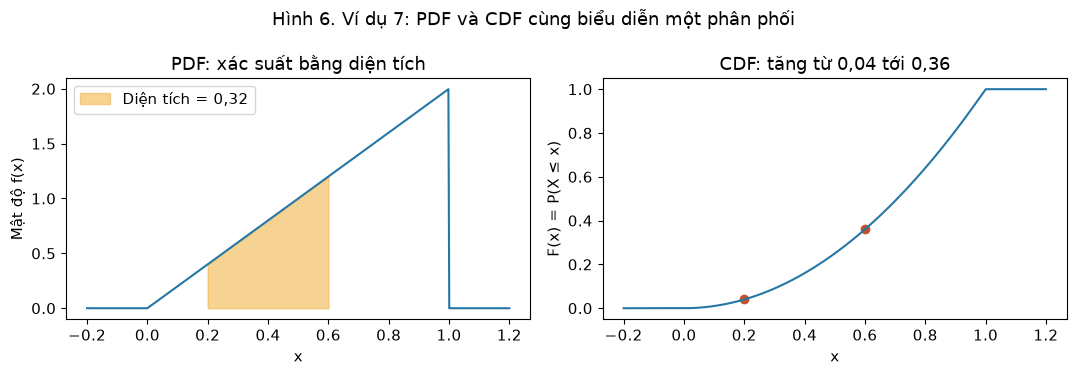

Diện tích khoảng cần tính: 0.32000000000000006


In [14]:
luoi = np.linspace(-0.2,1.2,500)
pdf_tam_giac = np.where((luoi>0)&(luoi<1),2*luoi,0)
cdf_tam_giac = np.clip(luoi,0,1)**2
fig,axes = plt.subplots(1,2,figsize=(11,3.8))
axes[0].plot(luoi,pdf_tam_giac,color="#2677A6")
vung = np.linspace(0.2,0.6,100)
axes[0].fill_between(vung,2*vung,color="#F1B44C",alpha=0.6,label="Diện tích = 0,32")
axes[0].set(xlabel="x",ylabel="Mật độ f(x)",title="PDF: xác suất bằng diện tích");axes[0].legend()
axes[1].plot(luoi,cdf_tam_giac,color="#2677A6")
axes[1].scatter([0.2,0.6],[0.2**2,0.6**2],color="#C4512A")
axes[1].set(xlabel="x",ylabel="F(x) = P(X ≤ x)",title="CDF: tăng từ 0,04 tới 0,36")
fig.suptitle("Hình 6. Ví dụ 7: PDF và CDF cùng biểu diễn một phân phối");fig.tight_layout();plt.show()
print("Diện tích khoảng cần tính:",integrate.quad(lambda t:2*t,0.2,0.6)[0])

### Ví dụ 8 — Kỳ vọng và phương sai từ pdf

Tổng có trọng số của biến rời rạc trở thành tích phân có trọng số cho biến có mật độ:
$$E(X)=\int_{-\infty}^{\infty}x f_X(x)\,dx,\qquad
\operatorname{Var}(X)=\int_{-\infty}^{\infty}(x-\mu)^2f_X(x)\,dx.$$
Giả sử các tích phân hữu hạn; ta vẫn có $\operatorname{Var}(X)=E(X^2)-[E(X)]^2$, với $E(X^2)=\int x^2f_X(x)\,dx$.

**Ví dụ 8.** Với $f(x)=2x$ trên $(0,1)$ và 0 ở nơi khác:
$$E(X)=\int_0^1 2x^2\,dx=\frac23,\qquad E(X^2)=\int_0^1 2x^3\,dx=\frac12.$$
$$\operatorname{Var}(X)=\frac12-\frac49=\frac1{18}.$$
Mật độ tăng về phía 1 khiến kỳ vọng $2/3$ lớn hơn tâm khoảng $1/2$. Cell kiểm tra bằng tích phân số, rồi mô phỏng $X=\sqrt U$ với $U\sim U(0,1)$ vì $P(\sqrt U\le x)=x^2$ trên $(0,1)$.

In [15]:
e_lien_tuc = integrate.quad(lambda x:x*2*x,0,1)[0]
e2_lien_tuc = integrate.quad(lambda x:x*x*2*x,0,1)[0]
print("E(X), E(X²), Var(X):",e_lien_tuc,e2_lien_tuc,e2_lien_tuc-e_lien_tuc**2)
x_lien_tuc = np.sqrt(rng.uniform(size=20000))
print("Mô phỏng TB, Var:",x_lien_tuc.mean(),x_lien_tuc.var())
assert np.isclose(e_lien_tuc,2/3) and np.isclose(e2_lien_tuc-e_lien_tuc**2,1/18)

E(X), E(X²), Var(X): 0.6666666666666667 0.5 0.05555555555555547
Mô phỏng TB, Var: 0.6641481196661977 0.055581497025934935


## 6. Các phân phối liên tục đặc biệt

### Phân phối đều và Ví dụ 9 — Chờ xe buýt

$X\sim U(a,b)$ với $a<b$ có pdf $1/(b-a)$ trong $(a,b)$, bằng 0 ngoài khoảng. Mọi khoảng con có cùng độ dài có cùng xác suất, chứ mỗi điểm không có xác suất dương như biến đều rời rạc.

$$E(X)=\frac{a+b}{2},\qquad \operatorname{Var}(X)=\frac{(b-a)^2}{12}.$$
$$F_X(x)=\begin{cases}0,&x\le a,\\(x-a)/(b-a),&a<x<b,\\1,&x\ge b.\end{cases}$$

**Ví dụ 9.** Giả sử xe buýt đến đều trong 10 phút tiếp theo; số phút chờ $X\sim U(0,10)$. $P(2<X<5)=(5-2)/10=0{,}3$ và $E(X)=5$ phút. Đây là giả định mô hình cho bài toán, không phải khẳng định xe buýt thực tế luôn phân phối đều.

Cell sau vẽ lại hình dạng slide 52 và tô vùng từ 2 tới 5: cao 0,1 mỗi phút × rộng 3 phút = xác suất 0,3. Trong SciPy, `uniform(loc=a, scale=b-a)`; `scale` là chiều dài khoảng.

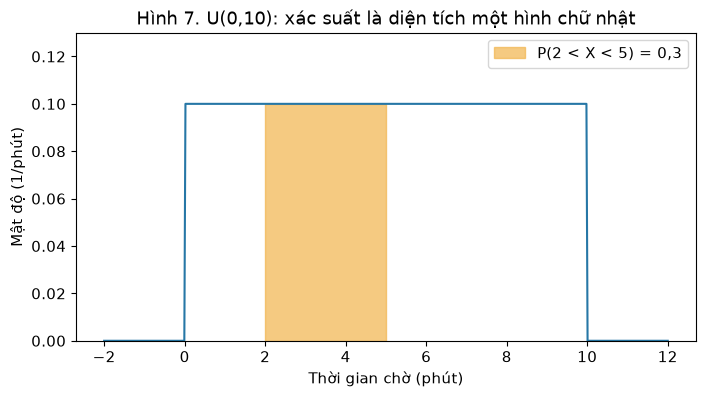

P(2<X<5) = 0.3 ; E = 5.0 ; Var = 8.333333333333332


In [16]:
a_deu,b_deu = 0,10
deu = stats.uniform(loc=a_deu,scale=b_deu-a_deu)
x_deu = np.linspace(-2,12,500)
fig,ax = plt.subplots()
ax.plot(x_deu,deu.pdf(x_deu),color="#2677A6")
vung = np.linspace(2,5,100)
ax.fill_between(vung,deu.pdf(vung),color="#F1B44C",alpha=0.7,label="P(2 < X < 5) = 0,3")
ax.set(xlabel="Thời gian chờ (phút)",ylabel="Mật độ (1/phút)",ylim=(0,0.13),
       title="Hình 7. U(0,10): xác suất là diện tích một hình chữ nhật")
ax.legend();plt.show()
print("P(2<X<5) =",deu.cdf(5)-deu.cdf(2),"; E =",deu.mean(),"; Var =",deu.var())

### Phân phối chuẩn, chuẩn hóa và Ví dụ 10

Với $\mu\in\mathbb R$, $\sigma>0$, ký hiệu $X\sim\mathcal N(\mu,\sigma^2)$ chỉ phân phối có pdf
$$f_X(x)=\frac1{\sigma\sqrt{2\pi}}\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right],\quad x\in\mathbb R.$$
$E(X)=\mu$ là tâm đối xứng; $\operatorname{Var}(X)=\sigma^2$ quyết định độ phân tán. Đường cong có dạng chuông. Phân phối chuẩn tắc $\mathcal N(0,1)$ có cdf ký hiệu $\Phi$.

**Chuẩn hóa:** $Z=(X-\mu)/\sigma\sim\mathcal N(0,1)$ và $P(X\le x)=\Phi((x-\mu)/\sigma)$. Trừ trung bình xóa vị trí; chia SD đo khoảng cách bằng số độ lệch chuẩn. $Z$ không có đơn vị. Chỉ chuẩn hóa một biến bất kỳ không làm nó tự thành chuẩn.

**Ví dụ 10.** Giả sử điểm thi chuẩn, trung bình 70 và SD 8. Điểm 86 có $z=(86-70)/8=2$: cao hơn trung bình 2 SD. Đó không phải xác suất 2 hay “gấp đôi trung bình”.

Ở hình tương tác sau, thử đổi SD trong khi giữ trung bình 70. Đường cong rộng hơn thì thấp hơn để tổng diện tích vẫn là 1. Đường đứng ở 86 cho biết cùng điểm này có $z$ khác nhau khi SD đổi.

In [17]:
mu_diem = 70
diem_quan_sat = 86
ds_sd = [4,8,12,16]
luoi_diem = np.linspace(0,140,500)
fig_chuan = go.Figure()
for i,sd in enumerate(ds_sd):
    fig_chuan.add_trace(go.Scatter(x=luoi_diem,y=stats.norm.pdf(luoi_diem,loc=mu_diem,scale=sd),
        mode="lines",visible=(i==1),name=f"SD = {sd}",
        hovertemplate="Điểm %{x:.1f}<br>Mật độ %{y:.4f}<extra></extra>"))
fig_chuan.add_vline(x=diem_quan_sat,line_dash="dash",line_color="#C4512A")
steps=[]
for i,sd in enumerate(ds_sd):
    steps.append(dict(method="update",label=str(sd),args=[{"visible":[j==i for j in range(len(ds_sd))]},
        {"title":{"text":f"Hình 8. μ = 70, SD = {sd}; điểm 86 có z = {(86-70)/sd:.2f}"}}]))
fig_chuan.update_layout(title="Hình 8. μ = 70, SD = 8; điểm 86 có z = 2",
    xaxis_title="Điểm thi (mô hình giả định)",yaxis_title="Mật độ (1/điểm)",
    sliders=[dict(active=1,currentvalue={"prefix":"SD = "},steps=steps)],height=430)
fig_chuan.show()
print("Ví dụ 10: z =",(86-70)/8)

Ví dụ 10: z = 2.0


### Quy tắc 68–95–99,7 và Ví dụ 11 — Dung tích chai

Với phân phối chuẩn, xác suất cách trung bình không quá 1, 2, 3 SD lần lượt xấp xỉ 68%, 95%, 99,7%. Các giá trị chính xác hơn là 0,682689; 0,954500; 0,997300. Quy tắc nói về phân phối chuẩn, không áp dụng tự động cho mọi dữ liệu.

**Ví dụ 11.** Giả sử dung tích chai $X\sim\mathcal N(500,2^2)$ ml. Khoảng [498,502] chứa xấp xỉ 68% chai; [496,504] chứa xấp xỉ 95%; xác suất trên 504 ml xấp xỉ 2,5%. Phần ngoài khoảng ±2 SD chia đều hai đuôi do đối xứng. Mô hình chỉ hợp lý khi quá trình ổn định và phân phối thực tế gần đối xứng.

Cell dựng ba vùng ±1, ±2, ±3 SD. Hãy đối chiếu phần diện tích tô với xác suất, rồi so xác suất đuôi đúng 0,02275 với mức làm tròn 2,5% trong quy tắc.

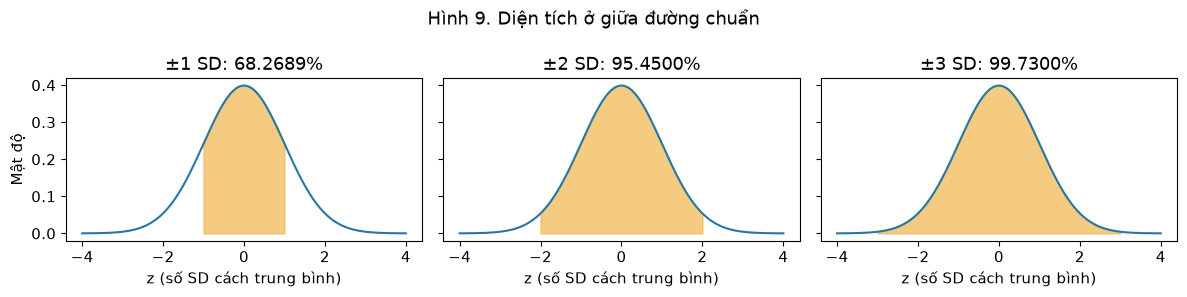

P(chai > 504 ml), chính xác theo mô hình: 0.022750131948179195


In [18]:
fig,axes = plt.subplots(1,3,figsize=(12,3),sharey=True)
z_luoi = np.linspace(-4,4,500)
for ax,k in zip(axes,[1,2,3]):
    ax.plot(z_luoi,stats.norm.pdf(z_luoi),color="#2677A6")
    vung=np.linspace(-k,k,200)
    ax.fill_between(vung,stats.norm.pdf(vung),color="#F1B44C",alpha=0.7)
    prob=stats.norm.cdf(k)-stats.norm.cdf(-k)
    ax.set(xlabel="z (số SD cách trung bình)",title=f"±{k} SD: {prob:.4%}")
axes[0].set_ylabel("Mật độ");fig.suptitle("Hình 9. Diện tích ở giữa đường chuẩn");fig.tight_layout();plt.show()
chai = stats.norm(loc=500,scale=2)
print("P(chai > 504 ml), chính xác theo mô hình:",chai.sf(504))

### Phân vị và Ví dụ 12 — Tính bằng SciPy

**Phân vị mức $p$** là ngưỡng $q_p$ sao cho $P(X\le q_p)=p$, với $0<p<1$. Với chuẩn:
$$q_p=\mu+\sigma\Phi^{-1}(p).$$
$\Phi^{-1}(p)$ trả về một **giá trị z**, không phải xác suất. Phân vị 0,95 để 95% diện tích bên trái, 5% bên phải; không phải một khoảng chứa 95% dữ liệu quanh trung bình.

**Ví dụ 12.** Dung tích chai có trung bình 500 ml, SD 2 ml. Tính (1) $P(X\le503)$ và $P(X>503)$; (2) $P(498<X<502)$; (3) $q_{0{,}95}$.

<details><summary>Đáp án và cách lập luận</summary><div><ol> <li>$z=(503-500)/2=1{,}5$, nên $P(X\le503)=\Phi(1{,}5)\approx0{,}9332$ và $P(X&gt;503)\approx0{,}0668$.</li> <li>$\Phi(1)-\Phi(-1)\approx0{,}6827$.</li> <li>$q_{0{,}95}=500+2(1{,}64485)\approx503{,}290$ ml.</li> </ol> <p><code>loc=500</code> là trung bình; <strong><code>scale=2</code> là SD</strong>, không phải phương sai 4. <code>cdf</code> là diện tích bên trái; <code>sf</code> là bên phải; <code>ppf</code> là phân vị.</p> </div></details>

Ta chạy đúng các phép tính để kiểm tra đáp án. Các ngưỡng đầu vào đo bằng ml; kết quả xác suất không có đơn vị, phân vị đầu ra vẫn đo bằng ml.

In [19]:
p_duoi_503 = stats.norm.cdf(503,loc=500,scale=2)
p_tren_503 = stats.norm.sf(503,loc=500,scale=2)
p_giua = stats.norm.cdf(502,loc=500,scale=2)-stats.norm.cdf(498,loc=500,scale=2)
q95 = stats.norm.ppf(0.95,loc=500,scale=2)
display(pd.DataFrame({"Đại lượng":["P(X≤503)","P(X>503)","P(498<X<502)","q0,95 (ml)"],
                      "Kết quả":[p_duoi_503,p_tren_503,p_giua,q95]}))

,Đại lượng,Kết quả
0,P(X≤503),0.93319
1,P(X>503),0.06681
2,P(498<X<502),0.68269
3,"q0,95 (ml)",503.28971


### Phân phối mũ và Ví dụ 13 — Thời gian chờ yêu cầu

Với **tham số tốc độ** $\lambda>0$, $X\sim\operatorname{Exp}(\lambda)$ có pdf $\lambda e^{-\lambda x}$ khi $x\ge0$, bằng 0 khi $x<0$. Phân phối lệch phải, dùng cho một số mô hình thời gian chờ. $E(X)=1/\lambda$, $\operatorname{Var}(X)=1/\lambda^2$, $P(X>t)=e^{-\lambda t}$ với $t\ge0$.

$\lambda$ đo số sự kiện trên đơn vị thời gian; $1/\lambda$ đo thời gian. Trong SciPy `expon(scale=1/lam)` dùng **scale**, không dùng tham số tốc độ như `scale=lam`.

**Ví dụ 13.** Giả sử thời gian chờ yêu cầu mới có phân phối mũ, trung bình 2 phút. (1) Xác định $\lambda$. (2) Tính xác suất chờ hơn 3 phút.

<details><summary>Đáp án và cách lập luận</summary><div><p>$$\lambda=1/2=0{,}5\text{ mỗi phút},\qquad P(X&gt;3)=\int_3^\infty0{,}5e^{-0{,}5x}\,dx=e^{-1{,}5}\approx0{,}2231.$$ Theo mô hình, khoảng 22,31% lần theo dõi chờ hơn 3 phút. Không suy ra mọi thời gian chờ đều phân phối mũ.</p> </div></details>

Trước khi chạy, tìm vùng diện tích bên phải 3 phút trong hình. Giá trị 0,2231 phải nằm trong [0,1], còn chiều cao đường mật độ được đo bằng $1/\text{phút}$.

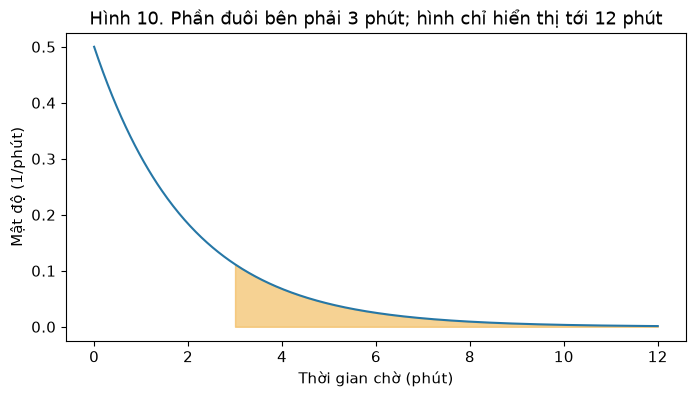

P(X>3) toàn bộ đuôi: 0.22313016014842982 ; E(X): 2.0


In [20]:
lam = 0.5  # Thử đổi tham số tốc độ (mỗi phút), E = 1/lam
mu_cho = 1/lam
cho = stats.expon(scale=mu_cho)
luoi_cho = np.linspace(0,12,500)
fig,ax = plt.subplots()
ax.plot(luoi_cho,cho.pdf(luoi_cho),color="#2677A6")
vung=np.linspace(3,12,300)
ax.fill_between(vung,cho.pdf(vung),color="#F1B44C",alpha=0.6)
ax.set(xlabel="Thời gian chờ (phút)",ylabel="Mật độ (1/phút)",
       title="Hình 10. Phần đuôi bên phải 3 phút; hình chỉ hiển thị tới 12 phút")
plt.show()
print("P(X>3) toàn bộ đuôi:",cho.sf(3),"; E(X):",cho.mean())

### Nhận diện $\chi^2$ và $t$ Student

Slide 66–67 giới thiệu hai phân phối để biết hình dạng và nơi chúng xuất hiện sau này; buổi này chưa dùng chúng để lập khoảng tin cậy hay kiểm định.

Phân phối **khi bình phương (chi-squared)** với $\nu>0$ bậc tự do, ký hiệu $\chi^2_\nu$, có mật độ
$$f(x)=\frac{x^{\nu/2-1}e^{-x/2}}{2^{\nu/2}\Gamma(\nu/2)},\quad x>0;\qquad f(x)=0\ (x<0).$$
Nó nhận giá trị không âm, lệch phải; $\nu$ thay đổi hình dạng. Mật độ tại đúng 0 không ảnh hưởng xác suất. $\Gamma$ là hàm Gamma; với số nguyên dương $m$, $\Gamma(m)=(m-1)!$.

Phân phối **$t$ Student** với $\nu>0$ bậc tự do có mật độ
$$f(x)=\frac{\Gamma((\nu+1)/2)}{\sqrt{\nu\pi}\Gamma(\nu/2)}\left(1+\frac{x^2}{\nu}\right)^{-(\nu+1)/2},\quad x\in\mathbb R.$$
Đường cong đối xứng quanh 0, đuôi dày hơn chuẩn tắc; khi $\nu$ tăng, nó tiến gần chuẩn. Không cần ghi nhớ hai biểu thức mật độ này để làm các bài vận dụng của buổi 7; cần phân biệt hình dạng, miền giá trị và ý nghĩa tham số bậc tự do.

Hình sau dùng SciPy để vẽ các mật độ đã có công thức; không phải phân phối của dữ liệu thu thập. Quan sát đuôi của $t$ và sự lệch phải của $\chi^2$.

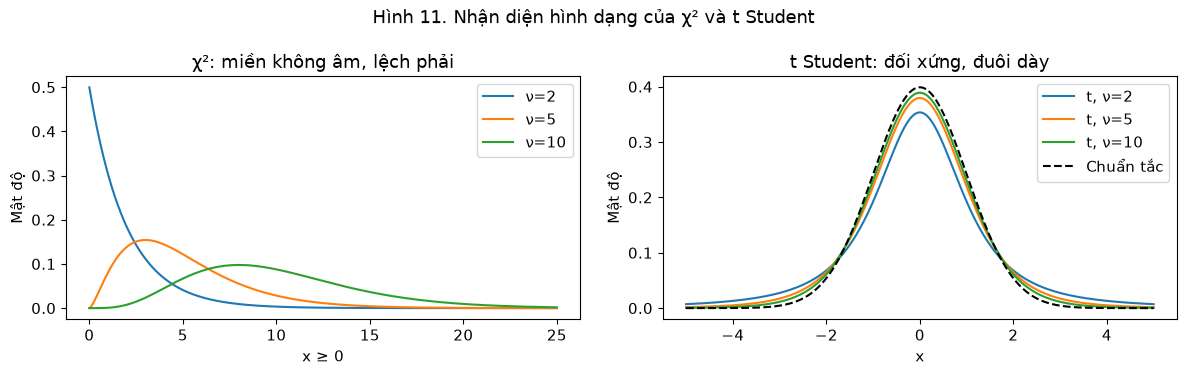

In [21]:
fig,axes=plt.subplots(1,2,figsize=(12,3.8))
luoi_duong=np.linspace(0.001,25,500)
luoi_t=np.linspace(-5,5,500)
for nu in [2,5,10]:
    axes[0].plot(luoi_duong,stats.chi2.pdf(luoi_duong,df=nu),label=f"ν={nu}")
    axes[1].plot(luoi_t,stats.t.pdf(luoi_t,df=nu),label=f"t, ν={nu}")
axes[1].plot(luoi_t,stats.norm.pdf(luoi_t),color="black",ls="--",label="Chuẩn tắc")
axes[0].set(xlabel="x ≥ 0",ylabel="Mật độ",title="χ²: miền không âm, lệch phải")
axes[1].set(xlabel="x",ylabel="Mật độ",title="t Student: đối xứng, đuôi dày")
for ax in axes:ax.legend()
fig.suptitle("Hình 11. Nhận diện hình dạng của χ² và t Student");fig.tight_layout();plt.show()

## 7. Định lý giới hạn trung tâm

### Vì sao nhiều tổng có dạng gần chuông?

Cho $X_1,X_2,\ldots$ iid, $E(X_i)=\mu$, $0<\operatorname{Var}(X_i)=\sigma^2<\infty$. Khi $n\to\infty$:
$$Z_n=\frac{S_n-n\mu}{\sigma\sqrt n}=\frac{\overline X_n-\mu}{\sigma/\sqrt n}\ \xrightarrow{\ d\ }\ \mathcal N(0,1).$$
Ký hiệu $\xrightarrow{d}$ nghĩa là **hội tụ theo phân phối**: cdf của $Z_n$ tiến gần cdf chuẩn tắc. Với cỡ mẫu đủ cho xấp xỉ phù hợp:
$$S_n\approx\mathcal N(n\mu,n\sigma^2),\qquad \overline X_n\approx\mathcal N(\mu,\sigma^2/n).$$

Các công thức kỳ vọng/phương sai đã đúng từ phần 3; CLT bổ sung **hình dạng xấp xỉ**. CLT không biến $X_i$ thành chuẩn, không xóa sự phụ thuộc và không có ngưỡng $n=30$ bảo đảm cho mọi phân phối. Khi phương sai bằng 0, chia cho $\sigma$ không thực hiện được; khi phương sai vô hạn, phát biểu này không áp dụng. Nếu các $X_i$ đã là chuẩn độc lập, tổng và trung bình là chuẩn **chính xác** với mọi $n$.

### Ví dụ 14 — Tổng và trung bình từ hộp thẻ

Rút $n$ lần độc lập, có hoàn lại từ hộp $0,0,1,1,1,2,3,3,4,4$, tính tổng/trung bình rồi lặp độc lập 5.000 lần; làm với $n=25$ và $n=100$.

1. So sánh hình dạng, tâm, độ phân tán của các tổng.
2. So sánh các trung bình.
3. Giải thích 25, 100, 5.000 có vai trò khác nhau thế nào.

<details><summary>Đáp án và cách lập luận</summary><div><p>Tổng gần dạng chuông, tâm tăng từ 47,5 lên 190; SD tăng từ 7,228 lên 14,457. Trung bình cũng gần chuông, cùng tâm 1,9; SD giảm từ 0,289 xuống 0,145. Các số 25,100 là <strong>cỡ mẫu mỗi lần</strong>, quyết định phương sai của tổng/trung bình và ảnh hưởng xấp xỉ chuẩn. Số 5.000 là <strong>số mẫu lặp</strong> dùng để vẽ phân phối thực nghiệm: tăng nó giúp thấy phân phối rõ hơn, không thay đổi phân phối lý thuyết của thống kê ở cỡ mẫu cố định.</p> </div></details>

Hai hình sau dựng lại slide 71–72. Hãy đọc đơn vị và giới hạn trục hoành trước khi so độ rộng. Histogram dùng `density=True` nên diện tích bằng 1; chiều cao không phải xác suất của từng giá trị. Tổng/trung bình từ hộp hữu hạn vẫn **rời rạc**, dù hình vẽ hoặc xấp xỉ trông mượt.

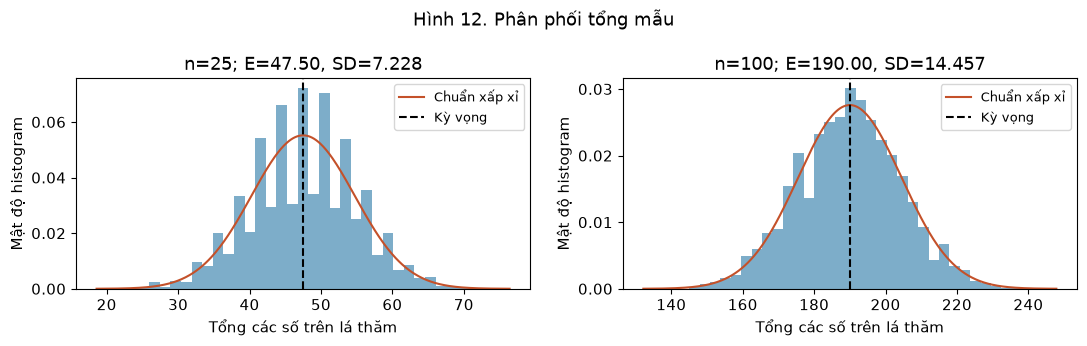

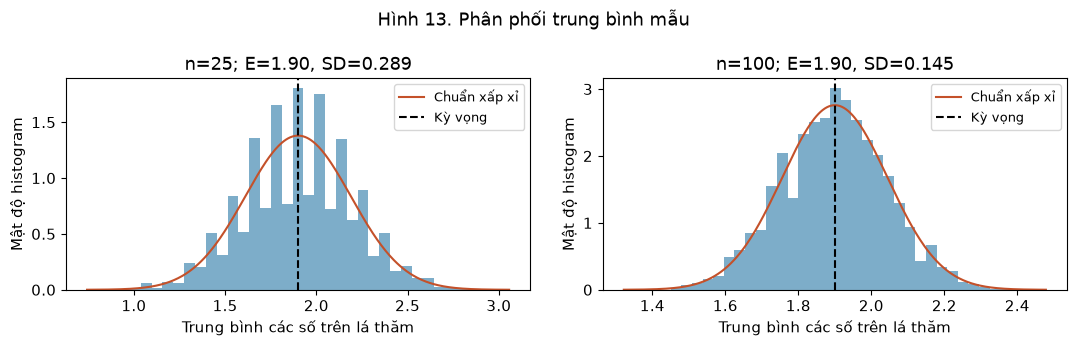

In [22]:
for bien,nhan,tieu_de in [("tong","Tổng các số trên lá thăm","Hình 12. Phân phối tổng mẫu"),
                             ("trung_binh","Trung bình các số trên lá thăm","Hình 13. Phân phối trung bình mẫu")]:
    fig,axes=plt.subplots(1,2,figsize=(11,3.5))
    for ax,n in zip(axes,[25,100]):
        du_lieu=ket_qua_hop[n][bien]
        mu=n*mu_hop if bien=="tong" else mu_hop
        sd=sd_hop*np.sqrt(n) if bien=="tong" else sd_hop/np.sqrt(n)
        ax.hist(du_lieu,bins=35,density=True,color="#2677A6",alpha=0.6)
        luoi=np.linspace(mu-4*sd,mu+4*sd,400)
        ax.plot(luoi,stats.norm.pdf(luoi,loc=mu,scale=sd),color="#C4512A",label="Chuẩn xấp xỉ")
        ax.axvline(mu,color="black",ls="--",label="Kỳ vọng")
        ax.set(xlabel=nhan,ylabel="Mật độ histogram",title=f"n={n}; E={mu:.2f}, SD={sd:.3f}")
        ax.legend(fontsize=9)
    fig.suptitle(tieu_de);fig.tight_layout();plt.show()

### Giữ phân phối gốc lệch phải, tăng cỡ mẫu

Mô phỏng trong slide 74–75 dùng **thời gian chờ mũ có kỳ vọng và SD đều 5 phút**. Với $n=1,5,30,100$, tạo 5.000 mẫu, tính trung bình và chuẩn hóa bằng **SD của trung bình** $5/\sqrt n$. Đường chuẩn tắc có cùng tâm 0, SD 1 cho mọi $n$; nhờ đó so sánh **hình dạng** công bằng hơn.

Cell sau dựng lại đủ bốn hình. `mau.mean(axis=1)` tạo 5.000 trung bình; `np.sqrt(n)` thay đổi theo cỡ mẫu, không theo số lần lặp. Tăng số lần lặp ở $n=1$ không làm phân phối mũ tự trở thành chuẩn.

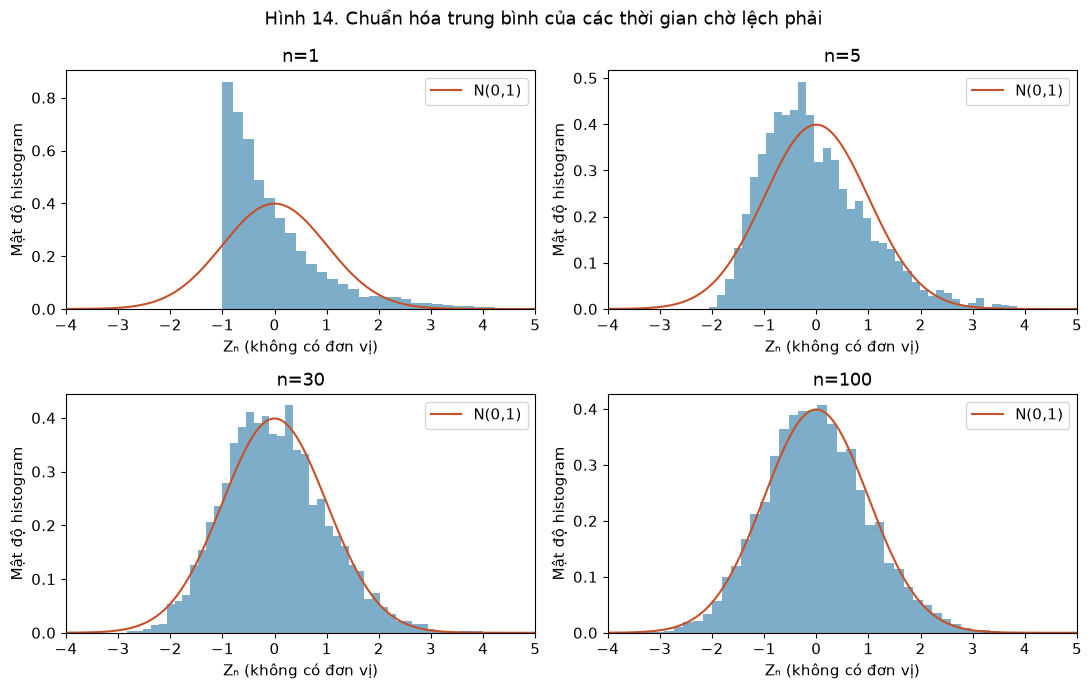

In [23]:
n_clt = [1,5,30,100]  # Thử đổi bốn cỡ mẫu; mỗi số cho một ô ở hình 2×2
lap_clt = 5000
mu_mu = sd_mu = 5.0
z_theo_n = {}
fig,axes=plt.subplots(2,2,figsize=(11,7))
luoi_z=np.linspace(-4,5,500)
for ax,n in zip(axes.flat,n_clt):
    mau=rng.exponential(scale=mu_mu,size=(lap_clt,n))
    z=(mau.mean(axis=1)-mu_mu)/(sd_mu/np.sqrt(n))
    z_theo_n[n]=z
    ax.hist(z,bins=45,density=True,color="#2677A6",alpha=0.6)
    ax.plot(luoi_z,stats.norm.pdf(luoi_z),color="#C4512A",label="N(0,1)")
    ax.set(xlabel="Zₙ (không có đơn vị)",ylabel="Mật độ histogram",title=f"n={n}",xlim=(-4,5))
    ax.legend()
fig.suptitle("Hình 14. Chuẩn hóa trung bình của các thời gian chờ lệch phải");fig.tight_layout();plt.show()

Với $n=1$, đường histogram lệch phải rõ. Khi $n$ tăng, độ lệch giảm và hình dạng tiến gần chuẩn; không phải tất cả đường ở $n=30$ sẽ trùng chuẩn. Trục hoành bị giới hạn để so sánh phần giữa, nên có thể không thấy một số kết quả rất xa ở đuôi.

Ở hình tương tác sau, thanh trượt đổi **cỡ mẫu** của các phân phối vừa mô phỏng. Rê chuột để đọc khoảng z và chiều cao mật độ; tổng diện tích các cột mới là 1. Cell dùng các kết quả đã tạo để tránh thay seed khi kéo thanh trượt.

In [24]:
fig_clt = go.Figure()
cac_n=list(z_theo_n)
for i,n in enumerate(cac_n):
    cao,bien=np.histogram(z_theo_n[n],bins=40,density=True)
    tam=(bien[:-1]+bien[1:])/2
    fig_clt.add_trace(go.Bar(x=tam,y=cao,width=np.diff(bien),visible=(i==0),
        name=f"Mô phỏng n={n}",opacity=0.65,
        hovertemplate="z ≈ %{x:.2f}<br>Mật độ %{y:.3f}<extra></extra>"))
fig_clt.add_trace(go.Scatter(x=luoi_z,y=stats.norm.pdf(luoi_z),mode="lines",name="Chuẩn tắc",
                           line={"color":"#C4512A"}))
steps=[]
for i,n in enumerate(cac_n):
    steps.append(dict(method="update",label=str(n),args=[{"visible":[j==i for j in range(len(cac_n))]+[True]},
        {"title":{"text":f"Hình 15. Cỡ mẫu n={n}; {lap_clt} mẫu lặp"}}]))
fig_clt.update_layout(title=f"Hình 15. Cỡ mẫu n={cac_n[0]}; {lap_clt} mẫu lặp",
    xaxis={"title":"Trung bình đã chuẩn hóa Zₙ","range":[-4,5]},yaxis_title="Mật độ histogram",
    sliders=[dict(currentvalue={"prefix":"Cỡ mẫu n = "},steps=steps)],height=450,bargap=0)
fig_clt.show()

### Ví dụ 15 — Trung bình thời gian xử lý

Thời gian xử lý một yêu cầu có trung bình 12 phút, SD 6 phút, phân phối cá thể lệch phải. Chọn ngẫu nhiên 64 yêu cầu độc lập. (1) Xấp xỉ phân phối trung bình. (2) Tính xác suất trung bình vượt 13,5 phút. (3) Nêu điều kiện quan trọng.

<details><summary>Đáp án và cách lập luận</summary><div><p>Giả sử các yêu cầu cùng quy luật phân phối, với phương sai hữu hạn dương: $$\overline X_{64}\approx\mathcal N\left(12,\frac{6^2}{64}\right),\quad \operatorname{SD}(\overline X_{64})=6/8=0{,}75\text{ phút}.$$ $$P(\overline X_{64}&gt;13{,}5)\approx P\left(Z&gt;\frac{13{,}5-12}{0{,}75}\right)=P(Z&gt;2)\approx0{,}0228.$$ Quan sát iid, phương sai hữu hạn và dương; chất lượng xấp xỉ còn phụ thuộc phân phối gốc. Thời gian từng yêu cầu không có SD 0,75; <strong>trung bình của 64 yêu cầu</strong> mới có SD này.</p> </div></details>

Cell tính bằng chuẩn với `scale=6/sqrt(64)`. Ta chưa mô phỏng một phân phối gốc cụ thể vì đề chỉ cho trung bình/SD và hình dạng lệch phải; tự chọn một phân phối rồi gọi đó là dữ liệu thật sẽ thêm giả định.

In [25]:
n_yeu_cau = 64
sd_trung_binh = 6/np.sqrt(n_yeu_cau)
print("SD trung bình (phút):",sd_trung_binh)
print("P(TB > 13.5), xấp xỉ CLT:",stats.norm.sf(13.5,loc=12,scale=sd_trung_binh))

SD trung bình (phút): 0.75
P(TB > 13.5), xấp xỉ CLT: 0.022750131948179195


### CLT cho roulette: tâm xấu đi, hình vẫn gần chuẩn (bổ trợ)

Theo hộp lợi nhuận $G$ ở phần 3, $E(G)=-1/19$, SD $\sqrt{1-1/19^2}$. Dựng lại STAT20 §4.18.2 với $n=10,100,1000,5000$: tổng tiền sau nhiều lượt dần có hình gần chuông, nhưng tâm ngày càng âm. CLT mô tả hình dạng và độ phân tán, không cải thiện một trò chơi có kỳ vọng âm.

Trong cell, `p=[18/38,20/38]` là trọng số của hai giá trị $+1,-1$ và tổng bằng 1. Hãy đọc trục x ở từng hình; bốn trục có đơn vị đô la nhưng phạm vi khác nhau.

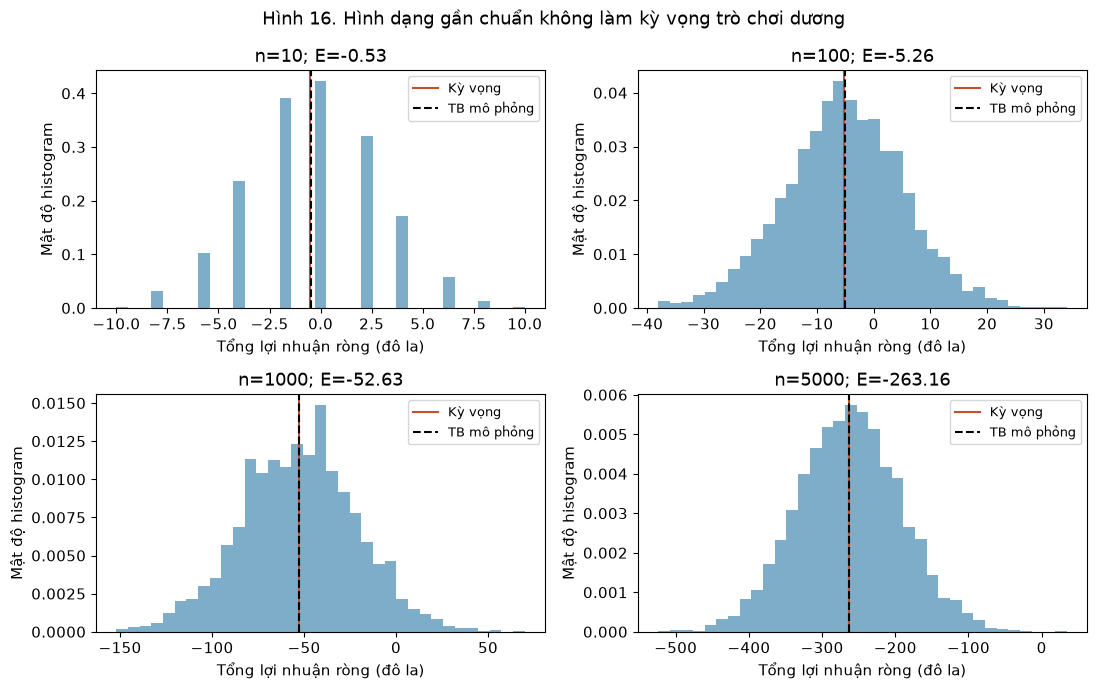

Trọng số của một lượt: [0.47368421 0.52631579] ; E(G): -0.05263157894736842 ; SD(G): 0.9986139979479092


In [26]:
gia_tri_gain=np.array([1,-1]);p_gain=np.array([18/38,20/38])
mu_gain=np.dot(gia_tri_gain,p_gain)
sd_gain=np.sqrt(np.dot((gia_tri_gain-mu_gain)**2,p_gain))
fig,axes=plt.subplots(2,2,figsize=(11,7))
for ax,n in zip(axes.flat,[10,100,1000,5000]):
    # Số lần thắng là nhị thức; tổng lợi nhuận = 2 × thắng − n.
    tong_gain=2*rng.binomial(n=n,p=18/38,size=5000)-n
    ax.hist(tong_gain,bins=35,density=True,color="#2677A6",alpha=0.6)
    ax.axvline(n*mu_gain,color="#C4512A",label="Kỳ vọng")
    ax.axvline(tong_gain.mean(),color="black",ls="--",label="TB mô phỏng")
    ax.set(xlabel="Tổng lợi nhuận ròng (đô la)",ylabel="Mật độ histogram",title=f"n={n}; E={n*mu_gain:.2f}")
    ax.legend(fontsize=9)
fig.suptitle("Hình 16. Hình dạng gần chuẩn không làm kỳ vọng trò chơi dương");fig.tight_layout();plt.show()
print("Trọng số của một lượt:",p_gain,"; E(G):",mu_gain,"; SD(G):",sd_gain)

Lấy nhị thức ở cell là cách mô phỏng tổng nhanh: mỗi lần thắng góp +1 và mỗi lần thua góp −1, nên tổng là $2B-n$. Nó giữ đúng phân phối của hộp 38 vé và tránh tạo mảng gồm hàng chục triệu lượt. Muốn quan sát một lượt riêng, thử `rng.choice(gia_tri_gain, size=10, p=p_gain)`.

## 8. Bài tập vận dụng từ slide

Các bài giữ nhãn gốc. Hãy nhận diện biến ngẫu nhiên, đơn vị, mô hình và điều kiện trước khi tính. Đáp án ở dưới từng đề; cell sau đáp án dùng để kiểm tra hoặc thử tham số.

### Bài tập 6 — Dung lượng USB

Dung lượng USB được khách hàng mua là $X$ (GB), với bảng:

| $x$ (GB) | 1 | 2 | 4 | 8 | 16 |
|---|---:|---:|---:|---:|---:|
| $p_X(x)$ | 0,05 | 0,10 | 0,35 | 0,40 | 0,10 |

1. Tính $E(X)$ và $E(X^2)$.
2. Tính phương sai từ định nghĩa.
3. Kiểm tra bằng công thức rút gọn.
4. Tính SD, ghi đúng đơn vị.

<details><summary>Đáp án và cách lập luận</summary><div><p>$$E(X)=1(0{,}05)+2(0{,}10)+4(0{,}35)+8(0{,}40)+16(0{,}10)=6{,}45\text{ GB}.$$ $$E(X^2)=0{,}05+0{,}40+5{,}60+25{,}60+25{,}60=57{,}25\text{ GB}^2.$$ $$\operatorname{Var}(X)=\sum_x(x-6{,}45)^2p_X(x)=15{,}6475\text{ GB}^2.$$ Kiểm tra: $57{,}25-6{,}45^2=15{,}6475$. SD $=\sqrt{15{,}6475}\approx3{,}9557$ GB. Dung lượng của một USB không thể là 6,45 GB trong bảng này; đó là dung lượng trung bình của cơ cấu bán hàng.</p> </div></details>

Bảng tính tiếp theo hiển thị từng số hạng của hai cách tính phương sai để bạn tìm lỗi nếu thay phân phối.

In [27]:
x_usb=np.array([1,2,4,8,16]);p_usb=np.array([0.05,0.10,0.35,0.40,0.10])
assert np.isclose(p_usb.sum(),1)
e_usb=np.dot(x_usb,p_usb);e2_usb=np.dot(x_usb**2,p_usb)
var_usb=np.dot((x_usb-e_usb)**2,p_usb)
display(pd.DataFrame({"GB":x_usb,"p":p_usb,"x p":x_usb*p_usb,"x² p":x_usb**2*p_usb,
                      "(x−μ)² p":(x_usb-e_usb)**2*p_usb}))
print("E / E(X²) / Var / SD:",e_usb,e2_usb,var_usb,np.sqrt(var_usb))
assert np.isclose(var_usb,e2_usb-e_usb**2) and np.isclose(var_usb,15.6475)

,GB,p,x p,x² p,(x−μ)² p
0,1,0.05,0.05,0.05,1.48512
1,2,0.10,0.20,0.40,1.98025
2,4,0.35,1.40,5.60,2.10087
3,8,0.40,3.20,25.60,0.96100
4,16,0.10,1.60,25.60,9.12025


E / E(X²) / Var / SD: 6.449999999999999 57.25 15.6475 3.955692101263697


### Bài tập 7 — Tìm đầu mút từ cdf

Biến liên tục $X$ nhận giá trị trên $[0,b]$, $b>0$, có
$$F_X(x)=\begin{cases}0,&x<0,\\x^2/9,&0\le x\le b,\\1,&x>b.\end{cases}$$
1. Tìm $b$.
2. Tìm pdf trên toàn bộ trục số.

<details><summary>Đáp án và cách lập luận</summary><div><p>Vì $X$ liên tục, cdf liên tục tại $b$. Do đó $b^2/9=1$; với $b&gt;0$, được $b=3$. Lấy đạo hàm trên từng khoảng: $$f_X(x)=\begin{cases}2x/9,&amp;0&lt;x&lt;3,\\0,&amp;\text{nơi khác}.\end{cases}$$ Giá trị mật độ tại hai đầu mút không đổi xác suất; cdf luôn tính đúng xác suất kể cả ở đầu mút.</p> </div></details>

Kiểm tra diện tích dưới pdf phải bằng 1. Nếu không dùng điều kiện liên tục để chọn $b$, công thức cdf có thể tạo một bước nhảy (khối xác suất tại đầu mút) hoặc vượt 1.

In [28]:
b_cdf=3.0
dien_tich = integrate.quad(lambda x:2*x/9,0,b_cdf)[0]
print("b =",b_cdf,"; tích phân pdf =",dien_tich)
assert np.isclose(dien_tich,1)

b = 3.0 ; tích phân pdf = 1.0


### Bài tập 8 — Tổng khối lượng trong thang máy

Trong **mô hình giả định của đề**, khối lượng người được chọn có phân phối chuẩn, trung bình 65 kg, SD 5 kg; các khối lượng độc lập. Một thang máy chở tối đa 10 người, tải trọng 700 kg. Tính xác suất 10 người được chọn ngẫu nhiên cùng vào mà không quá tải. Các số 65,5 không được trình bày như thống kê thực tế về dân số Việt Nam.

<details><summary>Đáp án và cách lập luận</summary><div><p>Đặt $S_{10}=X_1+\cdots+X_{10}$. Tổng của các biến chuẩn độc lập là chuẩn chính xác: $$S_{10}\sim\mathcal N(650,250),\quad \operatorname{SD}(S_{10})=5\sqrt{10}.$$ $$P(S_{10}\le700)=\Phi\left(\frac{700-650}{5\sqrt{10}}\right)\approx\Phi(3{,}1623)\approx0{,}9992.$$ Theo giả định mô hình, xác suất không quá tải khoảng 99,92%. Đây là tổng khối lượng, không phải trung bình khối lượng và không cần viện dẫn CLT.</p> </div></details>

Trong cell, thử đổi số người (không vượt mức 10 người của đề gốc) hoặc tải trọng để thấy xác suất thay đổi. Tính toán chỉ kiểm tra mô hình bài tập.

In [29]:
so_nguoi = 10  # Thử đổi trong 1..10
tai_trong = 700
mu_tong = 65*so_nguoi
sd_tong = 5*np.sqrt(so_nguoi)
print("Tâm / SD tổng (kg):",mu_tong,sd_tong)
print("P(tổng ≤ tải trọng), theo mô hình:",stats.norm.cdf(tai_trong,loc=mu_tong,scale=sd_tong))

Tâm / SD tổng (kg): 650 15.811388300841898
P(tổng ≤ tải trọng), theo mô hình: 0.9992172988709987


### Bài tập 9 — Khoảng cách từ nhà đến trường

Khoảng cách $X$ (km) của một sinh viên được chọn được **giả sử phân phối mũ**, kỳ vọng 5 km. Các khoảng cách của sinh viên được chọn iid.

1. Tính xác suất một sinh viên cách trường hơn 10 km.
2. Với 100 sinh viên, dùng CLT tính gần đúng xác suất **tổng** khoảng cách không quá 300 km.
3. Tính gần đúng xác suất **trung bình** của 100 sinh viên nằm trong (4,9;5,2) km.
4. Tính **chính xác** xác suất khoảng cách của **một** sinh viên nằm trong (4,9;5,2) km.
5. Tính gần đúng xác suất trung bình của 36 sinh viên trong cùng khoảng.

<details><summary>Đáp án và cách lập luận</summary><div><p>$E(X)=\operatorname{SD}(X)=5$ km, tốc độ $\lambda=1/5$ mỗi km.</p> <ol> <li>$P(X&gt;10)=e^{-2}\approx0{,}1353$.</li> <li>$S_{100}\approx\mathcal N(500,2500)$, SD 50 km; $P(S_{100}\le300)\approx\Phi(-4)\approx0{,}00003$.</li> <li>SD$(\overline X_{100})=0{,}5$ km, nên $\Phi(0{,}4)-\Phi(-0{,}2)\approx0{,}2347$.</li> <li>$P(4{,}9&lt;X&lt;5{,}2)=e^{-4{,}9/5}-e^{-5{,}2/5}\approx0{,}0219$.</li> <li>SD$(\overline X_{36})=5/6$ km; $\Phi(0{,}24)-\Phi(-0{,}12)\approx0{,}1426$.</li> </ol> <p>Câu 3 và 5 cùng khoảng nhưng SD trung bình khác nhau. Câu 4 dùng phân phối cá thể nên không thể thay bằng chuẩn của trung bình. Câu 2 ở đuôi xa ($z=-4$): CLT cho xấp xỉ như yêu cầu đề, độ chính xác tương đối ở đuôi có thể thấp; không gọi đó là xác suất chính xác.</p> </div></details>

Cell dùng mô hình mũ ở câu 1,4 và mô hình chuẩn xấp xỉ ở câu 2,3,5. Kiểm tra `scale` theo **đại lượng đang hỏi** trước khi chạy.

In [30]:
khoang_cach = stats.expon(scale=5)
dap_an9 = {
    "1. Một người >10 km (chính xác)":khoang_cach.sf(10),
    "2. Tổng100 ≤300 km (CLT)":stats.norm.cdf(300,loc=500,scale=50),
    "3. TB100 trong (4.9,5.2) (CLT)":stats.norm.cdf(5.2,loc=5,scale=0.5)-stats.norm.cdf(4.9,loc=5,scale=0.5),
    "4. Một người trong (4.9,5.2) (chính xác)":khoang_cach.cdf(5.2)-khoang_cach.cdf(4.9),
    "5. TB36 trong (4.9,5.2) (CLT)":stats.norm.cdf(5.2,loc=5,scale=5/6)-stats.norm.cdf(4.9,loc=5,scale=5/6)
}
display(pd.Series(dap_an9,name="Xác suất"))

1. Một người >10 km (chính xác)             0.13534
2. Tổng100 ≤300 km (CLT)                    0.00003
3. TB100 trong (4.9,5.2) (CLT)              0.23468
4. Một người trong (4.9,5.2) (chính xác)    0.02186
5. TB36 trong (4.9,5.2) (CLT)               0.14259
Name: Xác suất, dtype: float64

### Bài tập 10 — Dự trữ linh kiện

Hệ thống cần một linh kiện thiết yếu. Khi hỏng, thay ngay; bỏ qua thời gian thay và giả sử không có nguyên nhân hỏng khác. Tuổi thọ các linh kiện iid, trung bình 100 giờ, SD 30 giờ. Dùng CLT ước tính số linh kiện để xác suất hoạt động liên tục **ít nhất 2.000 giờ** đạt **ít nhất 95%**. Số lượng tính cả linh kiện lắp ban đầu.

<details><summary>Đáp án và cách lập luận</summary><div><p>Đặt $S_n$ là tổng tuổi thọ của $n$ linh kiện. $E(S_n)=100n$, SD$(S_n)=30\sqrt n$, nên $$P(S_n\ge2000)\approx\Phi\left(\frac{100n-2000}{30\sqrt n}\right).$$ Muốn xấp xỉ này ít nhất 0,95: $$\frac{100n-2000}{30\sqrt n}\ge\Phi^{-1}(0{,}95)\approx1{,}64485.$$ Đặt $u=\sqrt n&gt;0$, giải $100u^2-49{,}3455u-2000\ge0$, rồi kiểm tra các số nguyên gần ngưỡng:</p> <table> <thead> <tr>   <th>$n$</th>   <th style="text-align:right">Xác suất CLT</th> </tr> </thead> <tbody> <tr>   <td>22</td>   <td style="text-align:right">0,9224</td> </tr> <tr>   <td>23</td>   <td style="text-align:right">0,9815</td> </tr> </tbody> </table> <p>Chọn <strong>23 linh kiện = 1 ban đầu + 22 dự phòng</strong>. Đây là ước tính theo CLT, không bảo đảm cho mọi phân phối tuổi thọ chỉ có trung bình/SD như đề. Không nên làm tròn căn $u$ trước rồi bình phương; kiểm tra trực tiếp các số nguyên $n$.</p> </div></details>

Cell tính các xác suất lân cận và chọn số nguyên nhỏ nhất đạt ngưỡng **theo xấp xỉ**. Nhìn độ nhảy từ 22 tới 23 để thấy vì sao phải kiểm tra nguyên.

In [31]:
moc_gio = 2000
nguong_prob = 0.95
ds_linh_kien = np.arange(18,27)
p_hoat_dong = stats.norm.cdf((100*ds_linh_kien-moc_gio)/(30*np.sqrt(ds_linh_kien)))
display(pd.DataFrame({"Tổng số linh kiện":ds_linh_kien,"P hoạt động ≥2000h (CLT)":p_hoat_dong}))
n_chon = int(ds_linh_kien[p_hoat_dong>=nguong_prob][0])
print("Chọn",n_chon,"linh kiện; dự phòng",n_chon-1,"(theo xấp xỉ CLT).")
assert n_chon==23

,Tổng số linh kiện,P hoạt động ≥2000h (CLT)
0,18,0.05805
1,19,0.22222
2,20,0.50000
3,21,0.76651
4,22,0.92239
5,23,0.98147
6,24,0.99675
7,25,0.99957
8,26,0.99996


Chọn 23 linh kiện; dự phòng 22 (theo xấp xỉ CLT).


## 9. Tự kiểm tra và chuẩn bị giữa kỳ

Kỳ vọng là trung tâm của **phân phối**, không nhất thiết một kết quả có thể xảy ra. Phương sai đo bình phương độ lệch, SD đưa về đơn vị gốc. Kỳ vọng cộng được dù phụ thuộc; muốn cộng phương sai phải kiểm tra độc lập hoặc xử lý hiệp phương sai. Với iid, tổng có SD $\sigma\sqrt n$, còn trung bình có SD $\sigma/\sqrt n$.

Chebyshev cho cận sai lệch khi có phương sai hữu hạn. Luật số lớn yếu giải thích trung bình ổn định theo xác suất; CLT giải thích phân phối của tổng/trung bình đã chuẩn hóa. Cả hai nói về việc lặp và tăng cỡ mẫu, không nói mỗi kết quả riêng sẽ tiến về trung bình.

Với pdf, xác suất là diện tích; cdf trả về diện tích bên trái. Nhận diện đều, chuẩn, mũ, $\chi^2$, $t$ Student bằng miền giá trị/hình dạng/tham số. Dùng chuẩn phải phân biệt SD và phương sai; `loc`/`scale` của SciPy phụ thuộc mô hình.

Trước buổi 8, làm lại Bài tập 1–10 khi đóng đáp án và ghi các câu chưa hiểu. Buổi 8 là kiểm tra giữa kỳ và giải đáp; ôn dữ liệu, thống kê mô tả, xác suất, biến ngẫu nhiên, nhận diện mô hình và tính xác suất/kỳ vọng/phương sai/SD từ buổi 1–7. Sau đó buổi 9 mới chuyển từ mẫu tới tổng thể và khoảng tin cậy.

### Nguồn và các điểm đã chuẩn hóa khi chuyển sang notebook

- [Slides/week07.pdf](../Slides/week07.pdf): giữ nội dung 94 trang, 15 Ví dụ, 10 Bài tập và các lời giải. Các hình luật số lớn, đều, chuẩn, tổng/trung bình và CLT được dựng bằng cell Python; seed chuyển từ 2026 trên slide sang 42 theo quy ước dự án nên kết quả mô phỏng khác chút.
- [STAT20 tiếng Việt](../STAT20_in_Vietnamese.html), §4.7–4.18: dùng để bổ trợ trực giác, mô hình hộp, xúc xắc, bước đi ngẫu nhiên, roulette; các biểu đồ xác suất được vẽ lại, các sơ đồ/ảnh được ghi nguồn tại từng hình S1–S5.
- Định nghĩa iid được viết qua cdf để bao gồm liên tục; “standard error” trong bản dịch nguồn được hiểu là **sai số chuẩn**, tức SD của thống kê, không thay thế SD của một quan sát.
- Sửa dòng R nguồn vô tình ghi 11 lá về hộp 10 lá đúng như slide; cdf đều nêu đủ ba miền; hàm của biến ngẫu nhiên phân biệt xác suất theo giá trị gốc với phân phối sau biến đổi.
- Giữ các điều kiện hữu hạn/độc lập trong slide; không gọi histogram hộp hữu hạn là biến liên tục, không coi chuẩn hóa làm mọi biến thành chuẩn. Các bài xe buýt, khối lượng, tuổi thọ và thời gian chờ đều là mô hình giả định.

Ngữ pháp đồ họa đã học ở buổi 3 vẫn gồm dữ liệu, ánh xạ thuộc tính hình ảnh, dạng hình học và các thành phần bổ sung. Việc dùng Matplotlib/Plotly để vẽ ở branch này chỉ thay công cụ thực hiện; các khái niệm đó giữ nguyên.

In [32]:
# Kiểm tra các mốc tính tay chính trước khi kết thúc Run All.
assert np.isclose(mu_dat,1.6) and np.isclose(var_dat,0.32)
assert np.isclose(np.dot(phan_banh,p_ban),7/12)
assert np.isclose(mu_hop,1.9) and np.isclose(var_hop,2.09)
assert np.isclose(var_usb,15.6475) and n_chon==23
print("Đã kiểm tra các mốc: cặp sản phẩm, phần bánh, hộp10 lá, USB và linh kiện.")

Đã kiểm tra các mốc: cặp sản phẩm, phần bánh, hộp10 lá, USB và linh kiện.
